In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skbio.diversity import alpha,beta_diversity
sns.set(context='talk',style='ticks',font_scale=1,rc ={'axes.spines.right': False,'axes.spines.top': False,'pdf.fonttype':42,'ps.fonttype':42},palette='colorblind')

In [2]:
samples=pd.read_csv('metadata_samples_clean_stage_II.tsv',sep='\t')
fmt_samples=pd.read_csv('metadata_fmts_clean_stage_II.tsv',sep='\t')
fmt_samples

,fmt_id,dataset,recipient_name,donor_name,pre_samples,post_samples,donor_sample,success,additional_donor_samples,fresh_frozen,related_donor,route,display_dataset,single_pre_sample,single_post_sample,single_post_timepoint,single_donor_sample
0,0,AggarwalaV_2021,1001095,1001099,1001095A,"1001095I,1001095K",1001099B,False,NaN,NaN,NaN,NaN,AggarwalaV_2021,1001095A,1001095I,427.0,1001099B
1,1,AggarwalaV_2021,1001166,1001175,1001166B,1001166G,1001175B,True,NaN,NaN,NaN,NaN,AggarwalaV_2021,1001166B,1001166G,33.0,1001175B
2,2,AggarwalaV_2021,1001216,1001217,1001216B,"1001216F,1001216H,1001216I",1001217B,False,NaN,NaN,NaN,NaN,AggarwalaV_2021,1001216B,1001216F,7.0,1001217B
3,3,AggarwalaV_2021,1001254,1001262,"1001254A,1001254B","1001254E,1001254F,1001254G,1001254H,1001254I,1...",1001262B,True,NaN,NaN,NaN,NaN,AggarwalaV_2021,1001254B,1001254G,44.0,1001262B
4,4,AggarwalaV_2021,1001270,1001271,1001270B,"1001270D,1001270F,1001270H,1001270J",1001271B,True,NaN,NaN,NaN,NaN,AggarwalaV_2021,1001270B,1001270H,45.0,1001271B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,291,CM_IaniroFMT4,GRAN160304,FATHER,GRAN160304_t0,GRAN160304_t30,DONOR3185_GRAN160304,True,NaN,NaN,NaN,NaN,This_study_IBD,GRAN160304_t0,GRAN160304_t30,30.0,DONOR3185_GRAN160304
222,292,CM_IaniroFMT4,MAIO200508,UNIVERSAL DONOR,MAIO200508_t0,MAIO200508_t30,DONOR6911_SUAL271006,False,NaN,NaN,NaN,NaN,This_study_MDRB,MAIO200508_t0,MAIO200508_t30,30.0,DONOR6911_SUAL271006
223,293,CM_IaniroFMT4,MELO010202,UNIVERSAL DONOR,MELO010202_t0,MELO010202_t30,DONOR5120_COKO200409-MELO041017,False,NaN,NaN,NaN,NaN,This_study_IBD,MELO010202_t0,MELO010202_t30,30.0,DONOR5120_COKO200409-MELO041017
224,294,CM_IaniroFMT4,MELO041017,FATHER,MELO041017_t0,MELO041017_t30,DONOR1118_MELO010202,False,NaN,NaN,NaN,NaN,This_study_MDRB,MELO041017_t0,MELO041017_t30,30.0,DONOR1118_MELO010202


In [3]:
metaphlan=pd.read_csv('metaphlan_profiles.tsv',sep='\t')
metaphlan

,dataset,profile_id,k__Archaea,k__Archaea|p__Candidatus_Thermoplasmatota,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae|g__Methanomassiliicoccaceae_unclassified,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae|g__Methanomassiliicoccaceae_unclassified|s__Methanomassiliicoccaceae_unclassified_SGB380,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae|g__Methanomassiliicoccaceae_unclassified|s__Methanomassiliicoccaceae_unclassified_SGB380|t__SGB380,...,k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_SGB9293|t__SGB9293,k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_parvirubra,k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_parvirubra|t__SGB9292,k__Bacteria|p__Proteobacteria|c__CFGB2395|o__OFGB2395|f__FGB2395|g__GGB6554,k__Bacteria|p__Proteobacteria|c__CFGB2395|o__OFGB2395|f__FGB2395|g__GGB6554|s__GGB6554_SGB9256,k__Bacteria|p__Proteobacteria|c__CFGB2395|o__OFGB2395|f__FGB2395|g__GGB6554|s__GGB6554_SGB9256|t__SGB9256,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Alteromonadales|f__Shewanellaceae,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Alteromonadales|f__Shewanellaceae|g__Shewanella,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Alteromonadales|f__Shewanellaceae|g__Shewanella|s__Shewanella_algae,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Alteromonadales|f__Shewanellaceae|g__Shewanella|s__Shewanella_algae|t__SGB10333
0,AggarwalaV_2021,SRR15123565,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AggarwalaV_2021,SRR15123564,1.22626,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AggarwalaV_2021,SRR15123563,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AggarwalaV_2021,SRR15123562,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AggarwalaV_2021,SRR15123561,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,ZouM_2019,RSZAXPI000315-20,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1705,ZouM_2019,RSZAXPI000314-19,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1706,ZouM_2019,RSZAXPI000313-18,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1707,ZouM_2019,RSZAXPI000312-17,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
sample_ids=[]
for x in fmt_samples.pre_samples:
    sample_ids+=x.split(',')
    
for x in fmt_samples.post_samples:
    sample_ids+=x.split(',')
    
for x in fmt_samples.donor_sample.dropna():
    sample_ids+=x.split(',')
    
sample_ids=pd.unique(sample_ids)
profile_ids=samples[samples.sample_name.isin(sample_ids)].profile_id.values

(array([  1.,   0.,   1.,   1.,   7.,   8.,  12.,  28.,  52.,  51.,  73.,
        106., 130., 130., 142., 104.,  71.,  48.,  33.,  30.,  13.,  13.,
          3.,   2.,   1.]),
 array([1.99999944, 1.99999948, 1.99999952, 1.99999956, 1.9999996 ,
        1.99999964, 1.99999969, 1.99999973, 1.99999977, 1.99999981,
        1.99999985, 1.99999989, 1.99999994, 1.99999998, 2.00000002,
        2.00000006, 2.0000001 , 2.00000014, 2.00000019, 2.00000023,
        2.00000027, 2.00000031, 2.00000035, 2.00000039, 2.00000044,
        2.00000048]),
 <BarContainer object of 25 artists>)

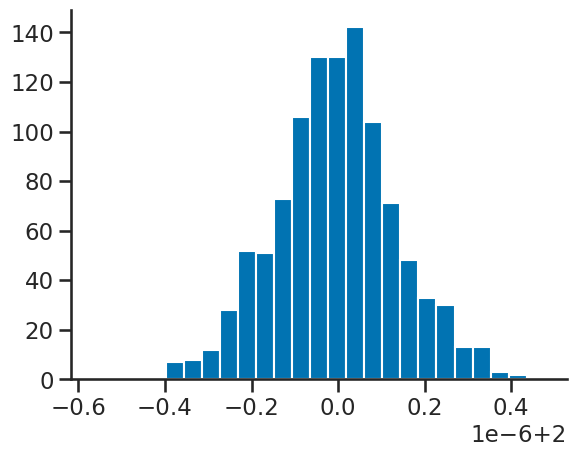

In [6]:
cols=[]
for col in metaphlan.columns:
    if 's__' in col and 't__' not in col:
        cols.append(col)
x=metaphlan[metaphlan.profile_id.isin(profile_ids)][cols].sum(axis=1).values
plt.hist(np.log10(x),bins=25)

In [7]:
profiles=metaphlan[metaphlan.profile_id.isin(profile_ids)][['profile_id']+cols]
profiles.index=profiles.profile_id
profiles=profiles.drop('profile_id',axis=1)
profiles.columns=profiles.columns.str.replace('Phocaeicola','Bacteroides')
profiles.columns=profiles.columns.str.replace('s__Prevotella_copri_clade_A','s__Prevotella_copri')
profiles.columns=profiles.columns.str.replace('s__Prevotella_copri_clade_C','s__Prevotella_copri')

In [ ]:
agora_species=pd.read_csv('micom_v1_dbs/agora103_refseq216_species_1/manifest.csv')
agora_species


In [829]:
agora_species[agora_species['genus']=='Blautia']

,organism,seedid,oxygenstat,metabolism,gram,mtype,genes,reactions,metabolites,draftcreator,...,class,order,family,genus,species,file,strain,kbaseid,id,summary_rank
138,"Blautia hansenii VPI C7-24, DSM 20583",Blautia hansenii DSM 20583 (537007.6),Obligate anaerobe,"Saccharolytic, fermentative, hydrogen used as ...",Positive,Commensal,633.0,2055.0,1191.0,Ines Thiele,...,Clostridia,Clostridiales,Lachnospiraceae,Blautia,Blautia hansenii,Blautia_hansenii.json,"Blautia hansenii VPI C7-24, DSM 20583",NaN,Blautia_hansenii,species
139,Blautia hydrogenotrophica DSM 10507,Blautia hydrogenotrophica DSM 10507 (476272.5),Obligate anaerobe,"Saccharolytic, fermentative, hydrogen used as ...",Positive,Commensal,827.0,1637.0,1177.0,Ines Thiele,...,Clostridia,Clostridiales,Lachnospiraceae,Blautia,Blautia hydrogenotrophica,Blautia_hydrogenotrophica.json,Blautia hydrogenotrophica DSM 10507,NaN,Blautia_hydrogenotrophica,species
140,NaN,NaN,Obligate anaerobe,"Saccharolytic, fermentative",Positive,NaN,NaN,NaN,NaN,NaN,...,Clostridia,Clostridiales,Lachnospiraceae,Blautia,Blautia obeum,Blautia_obeum.json,NaN,kb|g.1354,Blautia_obeum,species
141,Blautia producta DSM 2950,NaN,Obligate anaerobe,"Saccharolytic, fermentative, hydrogen used as ...",Positive,Commensal,1023.0,1235.0,966.0,chenry,...,Clostridia,Clostridiales,Lachnospiraceae,Blautia,Blautia producta,Blautia_producta.json,Blautia producta DSM 2950,kb|g.29565,Blautia_producta,species
142,Blautia wexlerae DSM 19850,NaN,Obligate anaerobe,"Saccharolytic, fermentative",Positive,NaN,855.0,1249.0,1006.0,Laura Kutt,...,Clostridia,Clostridiales,Lachnospiraceae,Blautia,Blautia wexlerae,Blautia_wexlerae.json,Blautia wexlerae DSM 19850,kb|g.207068,Blautia_wexlerae,species


In [624]:
agora_genus=pd.read_csv('micom_v1_dbs/agora103_refseq216_genus_1/manifest.csv')
agora_genus

,organism,seedid,oxygenstat,metabolism,gram,mtype,genes,reactions,metabolites,draftcreator,...,class,order,family,genus,species,file,strain,kbaseid,id,summary_rank
0,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva ATCC 49176 (592010.4),Facultative anaerobe,"Saccharolytic, fermentative or respiratory",Positive,Pathogen,631.0,2428.0,1250.0,Eugen Bauer,...,Bacilli,Lactobacillales,Aerococcaceae,Abiotrophia,Abiotrophia defectiva,Abiotrophia.json,Abiotrophia defectiva ATCC 49176,NaN,Abiotrophia,genus
1,Clostridium sticklandii DSM 519,Clostridium sticklandii DSM 519 (499177.3),Obligate anaerobe,"Proteolytic, non-sachharolytic",Positive,NaN,699.0,1270.0,959.0,Laura Kutt,...,Clostridia,Clostridiales,Peptostreptococcaceae,Acetoanaerobium,Acetoanaerobium sticklandii,Acetoanaerobium.json,Clostridium sticklandii DSM 519,kb|g.1828,Acetoanaerobium,genus
2,"Anaerobaculum hydrogeniformans OS1, ATCC BAA-1850",Anaerobaculum hydrogeniformans ATCC BAA-1850 (...,Obligate anaerobe,"Saccharolytic, fermentative",Negative,Commensal,670.0,1030.0,825.0,Ines Thiele,...,Synergistia,Synergistales,Synergistaceae,Acetomicrobium,Acetomicrobium hydrogeniformans,Acetomicrobium.json,"Anaerobaculum hydrogeniformans OS1, ATCC BAA-1850",NaN,Acetomicrobium,genus
3,NaN,Achromobacter xylosoxidans A8 (762376.5),Aerobe,Respiratory,Negative,NaN,NaN,NaN,NaN,NaN,...,Betaproteobacteria,Burkholderiales,Alcaligenaceae,Achromobacter,Achromobacter xylosoxidans,Achromobacter.json,NaN,NaN,Achromobacter,genus
4,NaN,NaN,Obligate anaerobe,NaN,Negative,NaN,NaN,NaN,NaN,NaN,...,Negativicutes,Acidaminococcales,Acidaminococcaceae,Acidaminococcus,NaN,Acidaminococcus.json,NaN,kb|g.2555,Acidaminococcus,genus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,NaN,NaN,Obligate anaerobe,NaN,NaN,NaN,NaN,NaN,NaN,Ines Thiele,...,Clostridia,Clostridiales,unclassified Clostridiales family,unclassified Clostridiales genus,NaN,unclassified_Clostridiales_genus.json,NaN,NaN,unclassified_Clostridiales_genus,genus
257,Enterobacteriaceae bacterium 9_2_54FAA,Enterobacteriaceae bacterium 9_2_54FAA (469613.3),Aerobe,Uncharacterized,Uncharacterized,Uncharacterized,1177.0,2209.0,1422.0,Ines Thiele,...,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,unclassified Enterobacteriaceae genus,Enterobacteriaceae bacterium 9_2_54FAA,unclassified_Enterobacteriaceae_genus.json,Enterobacteriaceae bacterium 9_2_54FAA,NaN,unclassified_Enterobacteriaceae_genus,genus
258,NaN,NaN,Obligate anaerobe,Uncharacterized,Uncharacterized,Uncharacterized,NaN,NaN,NaN,Ines Thiele,...,Erysipelotrichia,Erysipelotrichales,Erysipelotrichaceae,unclassified Erysipelotrichaceae genus,NaN,unclassified_Erysipelotrichaceae_genus.json,NaN,NaN,unclassified_Erysipelotrichaceae_genus,genus
259,NaN,NaN,Obligate anaerobe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Clostridia,Clostridiales,Lachnospiraceae,unclassified Lachnospiraceae genus,NaN,unclassified_Lachnospiraceae_genus.json,NaN,NaN,unclassified_Lachnospiraceae_genus,genus


In [625]:
species_list=[]
species_map={}
genus_list=[]
for col in profiles.columns:
    s=col.split('|')[-1].split('__')[1]
    g=col.split('|')[-2].split('__')[1]
    species_list.append(s)
    genus_list.append(g)
    species_map[(g,s)]=col
species_list

['Methanomassiliicoccaceae_unclassified_SGB380',
 'Candidatus_Methanomassiliicoccus_intestinalis',
 'Methanobrevibacter_smithii',
 'Methanosphaera_stadtmanae',
 'Actinobaculum_sp_oral_taxon_183',
 'Actinomyces_SGB17154',
 'Actinomyces_SGB17168',
 'Actinomyces_bouchesdurhonensis',
 'Actinomyces_dentalis',
 'Actinomyces_graevenitzii',
 'Actinomyces_naeslundii',
 'Actinomyces_oris',
 'Actinomyces_sp_ICM47',
 'Actinomyces_sp_ICM58',
 'Actinomyces_sp_S6_Spd3',
 'Gleimia_europaea',
 'Schaalia_turicensis',
 'Trueperella_pyogenes',
 'Bifidobacterium_adolescentis',
 'Bifidobacterium_animalis',
 'Bifidobacterium_bifidum',
 'Bifidobacterium_breve',
 'Bifidobacterium_catenulatum',
 'Bifidobacterium_dentium',
 'Bifidobacterium_longum',
 'Bifidobacterium_pseudocatenulatum',
 'Gardnerella_vaginalis',
 'Scardovia_wiggsiae',
 'Corynebacterium_durum',
 'Lawsonella_clevelandensis',
 'Kytococcus_sedentarius',
 'Rothia_dentocariosa',
 'Rothia_mucilaginosa',
 'Isoptericola_variabilis',
 'Arachnia_SGB15898',

In [821]:
species_count=0
species_cols=[]
species_table=pd.DataFrame()
unmapped=[]
for i in range(len(genus_list)):
    g=genus_list[i]
    s=species_list[i]
    if len(agora_species[(agora_species.genus==g)&(agora_species.species.str.contains(s.split('_')[-1]))])>0:
        species_count+=1
        species_cols.append(species_map[(g,s)])
        table=agora_species[(agora_species.genus==g)&(agora_species.species.str.contains(s.split('_')[-1]))].copy()
        table['tax']=species_map[(g,s)]
        species_table=pd.concat([species_table,table])
    else:
        unmapped.append(species_map[(g,s)])
print(species_count)

tmp=profiles[pd.unique(species_cols)].unstack().reset_index()
tmp.columns=['tax','samples','relative']
tmp=tmp.groupby(by=['samples','tax']).mean().reset_index()
species_models=pd.merge(species_table,tmp,on='tax')
#genus_models=genus_models.drop_duplicates()
species_models

381


,organism,seedid,oxygenstat,metabolism,gram,mtype,genes,reactions,metabolites,draftcreator,...,genus,species,file,strain,kbaseid,id,summary_rank,tax,samples,relative
0,Methanobrevibacter smithii ATCC 35061,Methanobrevibacter smithii ATCC 35061 (420247.6),Obligate anaerobe,"Uses carbon dioxide, hydrogen and formate as e...",Positive,Commensal,407.0,714.0,656.0,Ines Thiele,...,Methanobrevibacter,Methanobrevibacter smithii,Methanobrevibacter_smithii.json,Methanobrevibacter smithii ATCC 35061,NaN,Methanobrevibacter_smithii,species,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,CAVI230300_t0,0.0
1,Methanobrevibacter smithii ATCC 35061,Methanobrevibacter smithii ATCC 35061 (420247.6),Obligate anaerobe,"Uses carbon dioxide, hydrogen and formate as e...",Positive,Commensal,407.0,714.0,656.0,Ines Thiele,...,Methanobrevibacter,Methanobrevibacter smithii,Methanobrevibacter_smithii.json,Methanobrevibacter smithii ATCC 35061,NaN,Methanobrevibacter_smithii,species,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,CAVI230300_t7,0.0
2,Methanobrevibacter smithii ATCC 35061,Methanobrevibacter smithii ATCC 35061 (420247.6),Obligate anaerobe,"Uses carbon dioxide, hydrogen and formate as e...",Positive,Commensal,407.0,714.0,656.0,Ines Thiele,...,Methanobrevibacter,Methanobrevibacter smithii,Methanobrevibacter_smithii.json,Methanobrevibacter smithii ATCC 35061,NaN,Methanobrevibacter_smithii,species,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,COKO200409_t0,0.0
3,Methanobrevibacter smithii ATCC 35061,Methanobrevibacter smithii ATCC 35061 (420247.6),Obligate anaerobe,"Uses carbon dioxide, hydrogen and formate as e...",Positive,Commensal,407.0,714.0,656.0,Ines Thiele,...,Methanobrevibacter,Methanobrevibacter smithii,Methanobrevibacter_smithii.json,Methanobrevibacter smithii ATCC 35061,NaN,Methanobrevibacter_smithii,species,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,COKO200409_t30,0.0
4,Methanobrevibacter smithii ATCC 35061,Methanobrevibacter smithii ATCC 35061 (420247.6),Obligate anaerobe,"Uses carbon dioxide, hydrogen and formate as e...",Positive,Commensal,407.0,714.0,656.0,Ines Thiele,...,Methanobrevibacter,Methanobrevibacter smithii,Methanobrevibacter_smithii.json,Methanobrevibacter smithii ATCC 35061,NaN,Methanobrevibacter_smithii,species,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,COKO200409_t7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413955,Sutterella parvirubra YIT 11816,NaN,Facultative anaerobe,"Fermentative, respiratory",Negative,NaN,521.0,1014.0,836.0,Laura Kutt,...,Sutterella,Sutterella parvirubra,Sutterella_parvirubra.json,Sutterella parvirubra YIT 11816,kb|g.27712,Sutterella_parvirubra,species,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788B1,0.0
413956,Sutterella parvirubra YIT 11816,NaN,Facultative anaerobe,"Fermentative, respiratory",Negative,NaN,521.0,1014.0,836.0,Laura Kutt,...,Sutterella,Sutterella parvirubra,Sutterella_parvirubra.json,Sutterella parvirubra YIT 11816,kb|g.27712,Sutterella_parvirubra,species,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788B2,0.0
413957,Sutterella parvirubra YIT 11816,NaN,Facultative anaerobe,"Fermentative, respiratory",Negative,NaN,521.0,1014.0,836.0,Laura Kutt,...,Sutterella,Sutterella parvirubra,Sutterella_parvirubra.json,Sutterella parvirubra YIT 11816,kb|g.27712,Sutterella_parvirubra,species,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788T1,0.0
413958,Sutterella parvirubra YIT 11816,NaN,Facultative anaerobe,"Fermentative, respiratory",Negative,NaN,521.0,1014.0,836.0,Laura Kutt,...,Sutterella,Sutterella parvirubra,Sutterella_parvirubra.json,Sutterella parvirubra YIT 11816,kb|g.27712,Sutterella_parvirubra,species,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788T2,0.0


In [816]:
tmp2=tmp

In [817]:
genus_count=0
genus_cols=[]
genus_table=pd.DataFrame()
unmapped=[]
for i in range(len(genus_list)):
    g=genus_list[i]
    s=species_list[i]
    if len(agora_genus[(agora_genus.genus==g)])>0:
        genus_count+=1
        genus_cols.append(species_map[(g,s)])
        table=agora_genus[(agora_genus.genus==g)].copy()
        table['tax']=species_map[(g,s)]
        genus_table=pd.concat([genus_table,table])
    else:
        unmapped.append(species_map[(g,s)])
genus_count

tmp=profiles[pd.unique(genus_cols)].unstack().reset_index()
tmp.columns=['tax','samples','relative']
tmp=tmp.groupby(by=['samples','tax']).mean().reset_index()
genus_models=pd.merge(genus_table,tmp,on='tax')
#genus_models=genus_models.drop_duplicates()
genus_models

,organism,seedid,oxygenstat,metabolism,gram,mtype,genes,reactions,metabolites,draftcreator,...,genus,species,file,strain,kbaseid,id,summary_rank,tax,samples,relative
0,Methanomassiliicoccus luminyensis B10,NaN,Obligate anaerobe,Utilizes methanol,Positive,NaN,493.0,1001.0,831.0,Laura Kutt,...,Methanomassiliicoccus,Methanomassiliicoccus luminyensis,Methanomassiliicoccus.json,Methanomassiliicoccus luminyensis B10,kb|g.223963,Methanomassiliicoccus,genus,k__Archaea|p__Candidatus_Thermoplasmatota|c__T...,CAVI230300_t0,0.0
1,Methanomassiliicoccus luminyensis B10,NaN,Obligate anaerobe,Utilizes methanol,Positive,NaN,493.0,1001.0,831.0,Laura Kutt,...,Methanomassiliicoccus,Methanomassiliicoccus luminyensis,Methanomassiliicoccus.json,Methanomassiliicoccus luminyensis B10,kb|g.223963,Methanomassiliicoccus,genus,k__Archaea|p__Candidatus_Thermoplasmatota|c__T...,CAVI230300_t7,0.0
2,Methanomassiliicoccus luminyensis B10,NaN,Obligate anaerobe,Utilizes methanol,Positive,NaN,493.0,1001.0,831.0,Laura Kutt,...,Methanomassiliicoccus,Methanomassiliicoccus luminyensis,Methanomassiliicoccus.json,Methanomassiliicoccus luminyensis B10,kb|g.223963,Methanomassiliicoccus,genus,k__Archaea|p__Candidatus_Thermoplasmatota|c__T...,COKO200409_t0,0.0
3,Methanomassiliicoccus luminyensis B10,NaN,Obligate anaerobe,Utilizes methanol,Positive,NaN,493.0,1001.0,831.0,Laura Kutt,...,Methanomassiliicoccus,Methanomassiliicoccus luminyensis,Methanomassiliicoccus.json,Methanomassiliicoccus luminyensis B10,kb|g.223963,Methanomassiliicoccus,genus,k__Archaea|p__Candidatus_Thermoplasmatota|c__T...,COKO200409_t30,0.0
4,Methanomassiliicoccus luminyensis B10,NaN,Obligate anaerobe,Utilizes methanol,Positive,NaN,493.0,1001.0,831.0,Laura Kutt,...,Methanomassiliicoccus,Methanomassiliicoccus luminyensis,Methanomassiliicoccus.json,Methanomassiliicoccus luminyensis B10,kb|g.223963,Methanomassiliicoccus,genus,k__Archaea|p__Candidatus_Thermoplasmatota|c__T...,COKO200409_t7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957867,NaN,NaN,NaN,NaN,Negative,NaN,NaN,NaN,NaN,NaN,...,Sutterella,NaN,Sutterella.json,NaN,kb|g.27712,Sutterella,genus,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788B1,0.0
957868,NaN,NaN,NaN,NaN,Negative,NaN,NaN,NaN,NaN,NaN,...,Sutterella,NaN,Sutterella.json,NaN,kb|g.27712,Sutterella,genus,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788B2,0.0
957869,NaN,NaN,NaN,NaN,Negative,NaN,NaN,NaN,NaN,NaN,...,Sutterella,NaN,Sutterella.json,NaN,kb|g.27712,Sutterella,genus,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788T1,0.0
957870,NaN,NaN,NaN,NaN,Negative,NaN,NaN,NaN,NaN,NaN,...,Sutterella,NaN,Sutterella.json,NaN,kb|g.27712,Sutterella,genus,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,UWIBD01P788T2,0.0


(array([ 1.,  1.,  9., 17., 27., 31., 50., 66., 84., 49., 76., 74., 79.,
        67., 68., 71., 41., 48., 36., 34., 24., 27., 21., 20., 27.]),
 array([ 10.8354  ,  14.401984,  17.968568,  21.535152,  25.101736,
         28.66832 ,  32.234904,  35.801488,  39.368072,  42.934656,
         46.50124 ,  50.067824,  53.634408,  57.200992,  60.767576,
         64.33416 ,  67.900744,  71.467328,  75.033912,  78.600496,
         82.16708 ,  85.733664,  89.300248,  92.866832,  96.433416,
        100.      ]),
 <BarContainer object of 25 artists>)

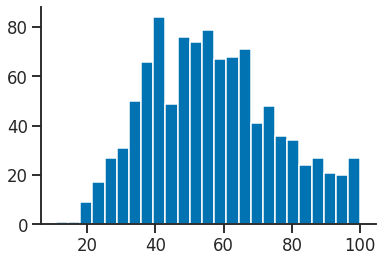

In [815]:
x=tmp.groupby(by=['samples','tax']).mean().reset_index().groupby(by='samples').sum()
plt.hist(x,bins=25)

In [628]:
from tqdm.auto import tqdm as progbar
cdiff_rel=10
invaded=pd.DataFrame()
for smp,df in progbar(genus_models.groupby(by='samples')):
    rel=df[df.genus!='Clostridioides'].relative.sum()*cdiff_rel/(100-cdiff_rel)
    idx=df[df.genus=='Clostridioides'].index.values
    df.loc[idx,'relative']=rel
    rel=df.groupby(by='genus').sum().relative.copy()
    df=df.drop_duplicates(subset='genus')
    df.loc[:,'relative']=rel[df.genus].values
    df.relative=df.relative/df.relative.sum()
    df=df[df.relative>10**-3]
    invaded=pd.concat([invaded,df],ignore_index=True)
invaded['reads']=invaded['relative']*10000
invaded.to_csv('nat-medicine-cdiff-01.csv',index=False)

  0%|          | 0/1048 [00:00<?, ?it/s]

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)
/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [825]:
from tqdm.auto import tqdm as progbar
cdiff_rel=10
invaded=pd.DataFrame()
for smp,df in progbar(species_models.groupby(by='samples')):
    rel=df[df.genus!='Clostridioides'].relative.sum()*cdiff_rel/(100-cdiff_rel)
    idx=df[df.genus=='Clostridioides'].index.values
    df.loc[idx,'relative']=rel
    rel=df.groupby(by='species').sum().relative.copy()
    df=df.drop_duplicates(subset='species')
    df.loc[:,'relative']=rel[df.species].values
    df.relative=df.relative/df.relative.sum()
    df=df[df.relative>10**-3]
    invaded=pd.concat([invaded,df],ignore_index=True)
invaded['reads']=invaded['relative']*10000
invaded.to_csv('nat-medicine-cdiff-01-species.csv',index=False)

  0%|          | 0/1048 [00:00<?, ?it/s]

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)
/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [827]:
invaded[invaded.genus=='Clostridioides']

,organism,seedid,oxygenstat,metabolism,gram,mtype,genes,reactions,metabolites,draftcreator,...,species,file,strain,kbaseid,id,summary_rank,tax,samples,relative,reads
7,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,CAVI230300_t0,0.1,1000.0
34,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,CAVI230300_t7,0.1,1000.0
51,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,COKO200409_t0,0.1,1000.0
69,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,COKO200409_t30,0.1,1000.0
97,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,COKO200409_t7,0.1,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34887,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,UWIBD01P788B1,0.1,1000.0
34930,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,UWIBD01P788B2,0.1,1000.0
34969,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,UWIBD01P788T1,0.1,1000.0
35015,NaN,NaN,Obligate anaerobe,"Proteolytic, few carbohydrates fermented",Positive,Opportunistic pathogen,NaN,NaN,NaN,NaN,...,Clostridioides difficile,Clostridioides_difficile.json,NaN,NaN,Clostridioides_difficile,species,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,UWIBD01P788T2,0.1,1000.0


(array([  3.,   6.,  11.,  28.,  81., 151., 252., 290., 168.,  47.]),
 array([ 9882.80167104,  9894.52150394,  9906.24133683,  9917.96116973,
         9929.68100262,  9941.40083552,  9953.12066842,  9964.84050131,
         9976.56033421,  9988.2801671 , 10000.        ]),
 <BarContainer object of 10 artists>)

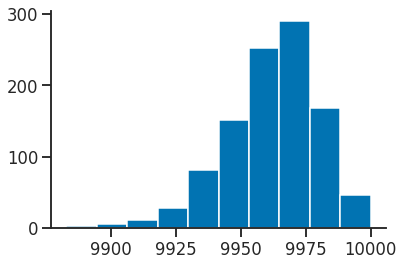

In [465]:
x=invaded.groupby(by='samples').sum().reads.values
plt.hist(x)

Text(0, 0.5, 'Frequency')

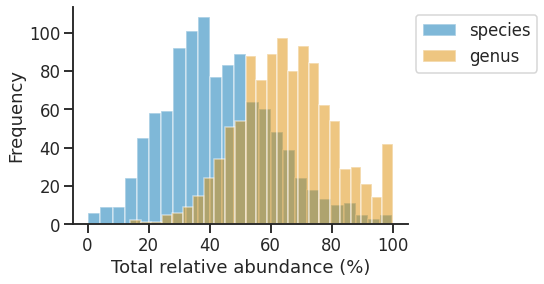

In [198]:

x=profiles[species_cols].sum(axis=1).values
plt.hist(x,bins=25,alpha=0.5,label='species')

x=profiles[genus_cols].sum(axis=1).values
plt.hist(x,bins=25,alpha=0.5,label='genus')

plt.legend(bbox_to_anchor=(1,1))

plt.xlabel('Total relative abundance (%)')
plt.ylabel('Frequency')

58.1477011731315
76.23317989593188


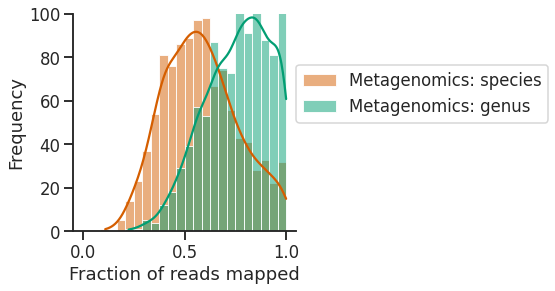

In [1162]:
y=profiles[profiles.columns[~profiles.columns.str.contains('SGB')].unique()].drop_duplicates().sum(axis=1)
plt.figure(figsize=(4,4))
x=profiles[pd.unique(species_cols)].sum(axis=1).drop_duplicates()
#x=(x/y.loc[x.index]).values*100
print(x.mean())
sns.histplot(data=x/100, kde=True,bins=np.linspace(0,1,25),color=sns.color_palette('colorblind')[3],label='Metagenomics: species')
x=profiles[pd.unique(genus_cols)].sum(axis=1).drop_duplicates()
#x=x/y.loc[x.index]
print(x.mean())
sns.histplot(data=x/100, kde=True,bins=np.linspace(0,1,25),color=sns.color_palette('colorblind')[2],label='Metagenomics: genus')
#plt.hist(,bins=25,alpha=0.5,label='Metagenomics: genus',density=True,color='g')

plt.legend(bbox_to_anchor=(1,1))

plt.xlabel('Total relative abundance (%)')
plt.ylabel('Frequency')
plt.legend(loc=(1,0.5))
plt.xlim(-.05,1.05)
plt.ylabel('Frequency')
plt.xlabel('Fraction of reads mapped')
plt.ylim(0,100)
plt.savefig('Model_abund_dist-ncbi-metagenomics-freq.pdf',bbox_inches='tight')

array([0.        , 0.04166667, 0.08333333, 0.125     , 0.16666667,
       0.20833333, 0.25      , 0.29166667, 0.33333333, 0.375     ,
       0.41666667, 0.45833333, 0.5       , 0.54166667, 0.58333333,
       0.625     , 0.66666667, 0.70833333, 0.75      , 0.79166667,
       0.83333333, 0.875     , 0.91666667, 0.95833333, 1.        ])

In [1155]:
x

profile_id
SRR15123565    61.15496
SRR15123564    51.45846
SRR15123563    99.91558
SRR15123562    82.96578
SRR15123561    99.82801
                 ...   
SRR11728431    86.64437
SRR11728430    83.25318
SRR11728428    87.85512
SRR11728426    85.13349
SRR11728424    79.08084
Length: 1057, dtype: float64

In [ ]:
ref_genus_cols=[]
ref_species_cols=[]
for x in profiles.columns:
    split=x.split('|')
    if len(split)==7:
        if 'SGB' not in split[-1]:
            ref_species_cols.append(x)
        if 'SGB' not in split[-2]:
            ref_genus_cols.append(x)
    elif len(split)==6:
        if 'SGB' not in split[-1]:
            ref_genus_cols.apppend(x)
        

65.53831904304604
77.11885008547064


Text(0, 0.5, 'Frequency')

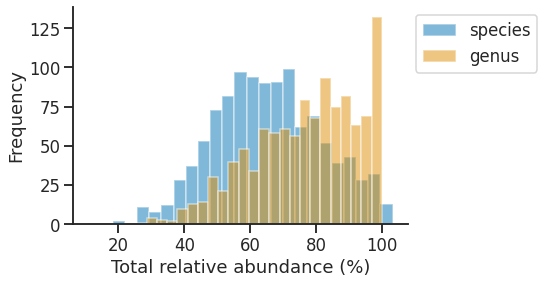

In [888]:
y1=profiles[pd.unique(ref_genus_cols)].drop_duplicates().sum(axis=1)
y2=profiles[pd.unique(ref_species_cols)].drop_duplicates().sum(axis=1)

x=profiles[pd.unique(species_cols)].drop_duplicates().sum(axis=1)
x=(x/y2.loc[x.index]).values*100
print(x.mean())
plt.hist(x,bins=25,alpha=0.5,label='species')

x=profiles[pd.unique(genus_cols)].drop_duplicates().sum(axis=1)
x=(x/y1.loc[x.index]).values*100
print(x.mean())
plt.hist(x,bins=25,alpha=0.5,label='genus')

plt.legend(bbox_to_anchor=(1,1))

plt.xlabel('Total relative abundance (%)')
plt.ylabel('Frequency')

In [918]:
profiles

,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae|g__Methanomassiliicoccaceae_unclassified|s__Methanomassiliicoccaceae_unclassified_SGB380,k__Archaea|p__Candidatus_Thermoplasmatota|c__Thermoplasmata|o__Methanomassiliicoccales|f__Methanomassiliicoccaceae|g__Methanomassiliicoccus|s__Candidatus_Methanomassiliicoccus_intestinalis,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_smithii,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanosphaera|s__Methanosphaera_stadtmanae,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinobaculum|s__Actinobaculum_sp_oral_taxon_183,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_SGB17154,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_SGB17168,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bouchesdurhonensis,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_dentalis,k__Bacteria|p__Actinobacteria|c__Actinobacteria|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_graevenitzii,...,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Enterococcus|s__Enterococcus_diestrammenae,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Enterococcus|s__Enterococcus_italicus,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Enterococcaceae|g__Vagococcus|s__Vagococcus_martis,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Leuconostocaceae|g__Leuconostoc|s__Leuconostoc_SGB48612,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Roseburia|s__Roseburia_SGB4939,k__Bacteria|p__Fusobacteria|c__Fusobacteriia|o__Fusobacteriales|f__Fusobacteriaceae|g__Fusobacterium|s__Fusobacterium_hwasookii,k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_SGB9293,k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_parvirubra,k__Bacteria|p__Proteobacteria|c__CFGB2395|o__OFGB2395|f__FGB2395|g__GGB6554|s__GGB6554_SGB9256,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Alteromonadales|f__Shewanellaceae|g__Shewanella|s__Shewanella_algae
profile_id,,,,,,,,,,,,,,,,,,,,,
SRR15123565,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.00222,0.0000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15123564,0.0,0.0,0.46884,0.75742,0.0,0.00000,0.00000,0.0000,0.00000,0.00861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15123563,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15123562,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR15123561,0.0,0.0,0.00000,0.00000,0.0,0.58620,0.94901,0.0000,0.02052,0.42189,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR11728431,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR11728430,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR11728428,0.0,0.0,0.00000,0.00000,0.0,0.00176,0.00000,0.0009,0.00406,0.00261,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
dataset_meta=pd.read_excel('Supplementary_tables.xlsx',sheet_name='Supplementary Table 1')
dataset_meta

,Dataset name,First Author,Location (of population),Year,Study design,Recipient disease,Median age,Mean age,Population (Age group),Sex,...,Fresh/frozen material,Grams/Volume of feces,Bowel cleansing,Route of delivery,Number of infusions,Follow-up samples after FMT,Primary (or main) outcome,Clinical outcome used for analysis,Clinical results (n° of patients who achieved the clinical outcome),Use of clinical data for analysis
0,AggarwalaV_2021,Aggarwala,USA,2021,"Retrospective, single-centre cohort",rCDI (in patients with or without IBD),NaN,NaN,adult,NaN,...,Both,NE,Split preparation,"Enteroscopy or colonoscopy, single","Enteroscopy or colonoscopy, single","36 h, 1-2-8-26 weeks, 1 and 5 years, after FMT",Resolution of CDI 6 months after FMT,Corresponding with primary outcome,9 of 13 patients,Yes
1,BaruchE_2020,Baruch,Israel,2020,"Single-centre, single-arm, nonrandomized clini...",melanoma patients refractory to anti PD-1,66.0,NaN,adult,"M=7, F=3",...,Frozen,50 g/NE (colonoscopy); 15 g/NE (capsules),"PEG, 3 liters","Colonoscopy, single, + 12 capsules every 2 wee...","Colonoscopy, single, + 12 capsules every 2 wee...","Days 7, 31 and 65 after FMT","Objective, image-based tumor regression (iRECI...",Corresponding with primary outcome,3 of 10 patients,Yes
2,BarYosephH_2020,Bar-Yoseph,Israel,2020,"Prospective, single-centre cohort",MDRB,58.2,NaN,adult,"M=10, F=5",...,Frozen,25-30g / 30 capsules,No,Capsules,30 capsules,Day 15 after FMT,MDRB eradication 30 days after FMT,Corresponding with primary outcome,9 of 15 patients,Yes
3,DammanC_2015,Damman,USA,2015,"Prospective, single-centre cohort",IBD (UC),41.0,NaN,adult,"M=3, F=4",...,Fresh,Variable amount/175 to 290 ml,"PEG, 4 liters","Colonoscopy, single","Colonoscopy, single","Weeks 1, 4 and 12 after FMT, or at the time of...",50% donor similarity 4 weeks after FMT,No,NE,No (metadata not available)
4,DavarD_2021,Davar,USA,2021,"Single-centre, single-arm, nonrandomized clini...",melanoma patients refractory to anti PD-1,61.0,NaN,adult,"M=11, F=4",...,Frozen,30 g/NE,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Weekly for 12 weeks after FMT and then every 3...,Tumor regression based on RECIST v1.1.,Corresponding with primary outcome,6 of 15 patients,Yes
5,GollR_2020,Goll,Norway,2020,Sub-analysis of data from a single-centre rand...,IBS,48.0,NaN,adult,"M=6, F=16",...,Both,50-80 g/250 ml,standard bowel lavage with sodium picosulphate...,"Colonoscopy, single","Colonoscopy, single",At months 6 and 12 after FMT,Symptom relief>75 points (as assessed by IBS-S...,Corresponding with primary outcome,20 of 30 patients,Yes
6,HouriganS_2019,Hourigan,USA,2019,"Prospective, single-centre cohort",rCDI,12.0,NaN,pediatric,NaN,...,Both,100 g/400 ml,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful)
7,IaniroG_2020,Ianiro,Italy,2020,Single-centre randomized clinical trial,TKI-induced diarrhoea,63.0,NaN,adult,"M=8, F=2",...,Fresh,At least 50 g/250 ml,"PEG, 4 liters","Colonoscopy, single","Colonoscopy, single","Weeks 1, 2, 4, and 8 after FMT",Resolution of TKI-dependent diarrhea 4 weeks a...,Corresponding with primary outcome,7 of 10 patients,Yes
8,KongL_2020,Kong,France,2020,Sub-analysis of data from a single-centre rand...,IBD (CD),31.5,NaN,adult,"M=5, F=3",...,Fresh,50–100 g/250–350 ml,"PEG, 4 liters","Colonoscopy, single","Colonoscopy, single","Weeks 2, 6, 10, 14, 18, and 24 after FMT",NE,No,NE,No (metadata not available)
9,KoopenAM_2021,Koopen,The Netherlands,2021,Single-centre randomized clinical trial,metabolic syndrome,51.5,NaN,adult,"M=12, F=0",...,Fresh,150g / 500ml,"PEG, 2-3 liters",Nasoduodenal tube (single),Nasoduodenal tube (single),"At weeks −2, 0, 3, 6, and 12 after FMT",Changes in the gut microbiota composition and ...,No,NE,No (metadata not available)


In [13]:
#growth_rates = pd.read_pickle('12202023_natmed_growth_rates_tradeoff_pfba.pkl').reset_index()
tmp1 = pd.read_pickle('12062023_natmed_growth_rates_tradeoff_pfba.pkl').reset_index()
tmp2 = pd.read_pickle('12202023_natmed_growth_rates_tradeoff_pfba.pkl').reset_index()
tmp=pd.concat([tmp1,tmp2],ignore_index=True)
growth_rates=tmp
growth_data=pd.merge(growth_rates,samples[['subject_name','profile_id','sample_type','time_point_days','dataset']],left_on='sample',right_on='profile_id')
growth_data=pd.merge(growth_data,dataset_meta,left_on='dataset',right_on='Dataset name')
rcdi_growth=growth_data[growth_data['Recipient disease'].str.contains('rCDI')]

cdiff_growth=rcdi_growth[(rcdi_growth.compartments=='Clostridioides')].copy()
cdiff_growth['log_growth']=np.log10(cdiff_growth['growth_rate'])
idx=cdiff_growth[cdiff_growth['log_growth']<-6].index
cdiff_growth.loc[idx,'log_growth']=-6
shannon=growth_rates.groupby(by=['sample','tradeoff']).apply(lambda df: alpha.shannon(df.abundance)).reset_index()
shannon.columns=['sample','tradeoff','shannon']
cdiff_growth=pd.merge(cdiff_growth,shannon,on=['sample','tradeoff'])
cdiff_growth

,compartments,growth_rate,abundance,sample,condition,tradeoff,subject_name,profile_id,sample_type,time_point_days,...,Bowel cleansing,Route of delivery,Number of infusions,Follow-up samples after FMT,Primary (or main) outcome,Clinical outcome used for analysis,Clinical results (n° of patients who achieved the clinical outcome),Use of clinical data for analysis,log_growth,shannon
0,Clostridioides,0.005132,0.100362,ERR4290679,+cdiff,0.80,R16,ERR4290679,recipient-after,365.0,...,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-2.289743,1.741821
1,Clostridioides,0.005510,0.100362,ERR4290679,+cdiff,0.90,R16,ERR4290679,recipient-after,365.0,...,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-2.258825,1.741821
2,Clostridioides,0.016132,0.100362,ERR4290679,+cdiff,1.00,R16,ERR4290679,recipient-after,365.0,...,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-1.792315,1.741821
3,Clostridioides,0.023810,0.100362,ERR4290679,+cdiff,0.75,R16,ERR4290679,recipient-after,365.0,...,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-1.623236,1.741821
4,Clostridioides,0.000003,0.100362,ERR4290679,+cdiff,0.85,R16,ERR4290679,recipient-after,365.0,...,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-5.487856,1.741821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,Clostridioides,0.000401,0.100200,SRR8667783,+cdiff,0.90,R14,SRR8667783,recipient-after,115.5,...,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-3.396318,1.926348
2046,Clostridioides,0.004901,0.100200,SRR8667783,+cdiff,1.00,R14,SRR8667783,recipient-after,115.5,...,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-2.309687,1.926348
2047,Clostridioides,0.217196,0.100200,SRR8667783,+cdiff,0.75,R14,SRR8667783,recipient-after,115.5,...,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-0.663148,1.926348
2048,Clostridioides,0.003819,0.100200,SRR8667783,+cdiff,0.85,R14,SRR8667783,recipient-after,115.5,...,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-2.418016,1.926348


<Axes: xlabel='tradeoff', ylabel='0'>

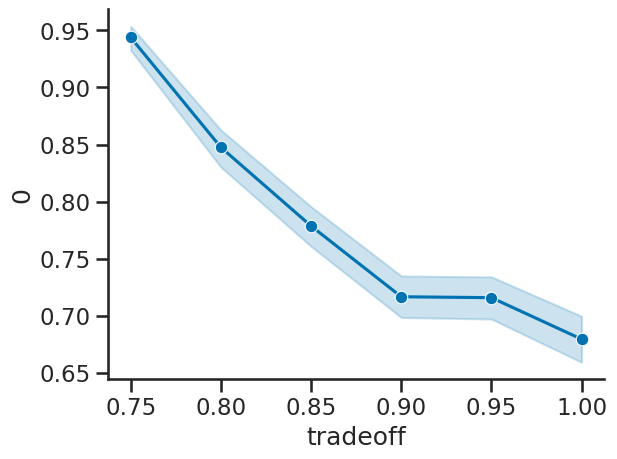

In [11]:
tmp1 = pd.read_pickle('12062023_natmed_growth_rates_tradeoff_pfba.pkl').reset_index()
tmp2 = pd.read_pickle('12202023_natmed_growth_rates_tradeoff_pfba.pkl').reset_index()

tmp=pd.concat([tmp1,tmp2],ignore_index=True)

res=tmp.groupby(by=['tradeoff','sample']).apply(lambda df: df[df['growth_rate']>10**-6].shape[0]/df.shape[0]).reset_index()
sns.lineplot(x='tradeoff',y=0,data=res,marker='o')

In [12]:
tmp

,compartments,growth_rate,abundance,sample,condition,tradeoff
0,Bifidobacterium,3.731243e-01,0.269990,CAVI230300,+cdiff,0.80
1,Blautia,6.831576e-02,0.050699,CAVI230300,+cdiff,0.80
2,Clostridioides,1.350089e-01,0.100105,CAVI230300,+cdiff,0.80
3,Enterococcus,4.932524e-01,0.365922,CAVI230300,+cdiff,0.80
4,Lactobacillus,2.641333e-01,0.195873,CAVI230300,+cdiff,0.80
...,...,...,...,...,...,...
159915,Roseburia,1.034498e-08,0.043685,UWIBD01P788T3,+cdiff,0.95
159916,Ruminococcus,2.551977e-09,0.001811,UWIBD01P788T3,+cdiff,0.95
159917,Streptococcus,2.048322e-08,0.025346,UWIBD01P788T3,+cdiff,0.95
159918,Sutterella,2.510874e-09,0.007122,UWIBD01P788T3,+cdiff,0.95


LinregressResult(slope=-1.9981835878051577, intercept=0.5123606094171897, rvalue=-0.22517789115405923, pvalue=2.6325324826721913e-05, stderr=0.46888977179372926, intercept_stderr=0.8317447199790818)
0.05070508266458935


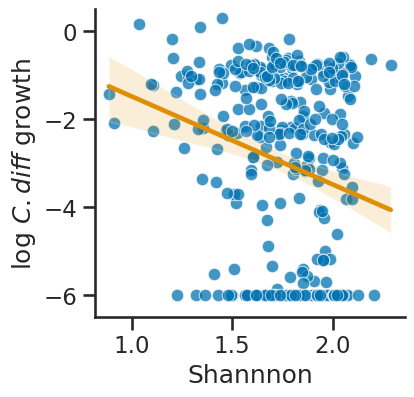

In [15]:
from scipy.stats import linregress
for idx,df in cdiff_growth.groupby(by='tradeoff'):
    if idx==0.9:
        plt.figure(figsize=(4,4))
        df['log_shannon']=np.exp(df.shannon)
        sns.scatterplot(x='shannon',y='log_growth',data=df,alpha=0.75)
        sns.regplot(x='shannon',y='log_growth',data=df,scatter=False,color=sns.color_palette('colorblind')[1])
        fit=linregress(df.shannon,df.log_growth)
        print(fit)
        print(fit.rvalue**2)
        plt.xlabel('Shannnon')
        plt.ylabel('log $C. diff$ growth')
        plt.ylim(-6.5,.5)
        #plt.xlim(1.25,3.25)
        #plt.savefig('log-cdiff-vs-shannon.pdf',bbox_inches='tight')

In [18]:
0.22517789115405923**2

0.05070508266458935

<AxesSubplot:xlabel='tradeoff', ylabel='0'>

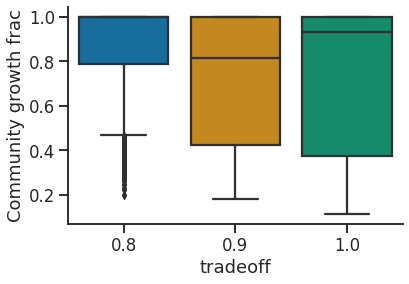

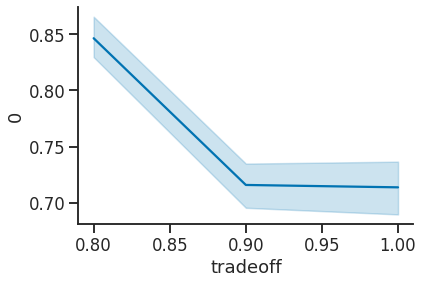

In [992]:
frac=growth_data.groupby(by=['tradeoff','sample']).apply(lambda df: df[df['growth_rate']>10**-6].shape[0]/df.shape[0])
sns.boxplot(x='tradeoff',y=0,data=frac.reset_index())
plt.ylabel('Community growth frac')
plt.figure()
sns.lineplot(x='tradeoff',y=0,data=frac.reset_index())

In [1129]:
cdiff_growth['Clinical results (n° of patients who achieved the clinical outcome)'].unique()

array(['8 of 8 patients', '16 of 19 patients', 'NE', '21 of 21 patients',
       '9 of 13 patients', '6 of 6 patients', '9 of 9 patients'],
      dtype=object)

Ttest_indResult(statistic=3.0923256944233075, pvalue=0.002308711327653719)
Ttest_indResult(statistic=1.598480629583971, pvalue=0.11298753168229936)
Ttest_indResult(statistic=-0.7044207345003487, pvalue=0.48284847173063195)


/tmp/ipykernel_2363674/1046700322.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Pre-FMT','Post-FMT','Donor'],rotation=0)


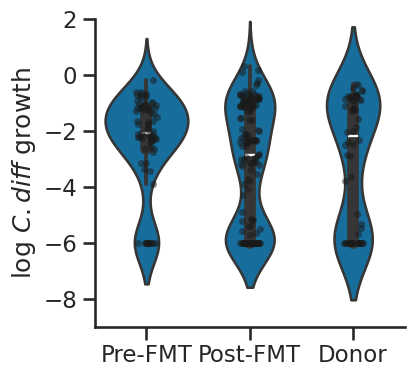

In [17]:
from scipy.stats import ttest_ind
for idx,df in cdiff_growth.groupby(by='tradeoff'):
    if idx == 0.9:
        fig,ax=plt.subplots(1,1,figsize=(4,4,))
        sns.violinplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after','donor'])
        sns.stripplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after','donor'],color='k',alpha=0.5)
        plt.xlabel('')
        plt.ylim(-9,2)
        
        x1=df[df.sample_type=='recipient-before']['log_growth']
        x2=df[df.sample_type=='recipient-after']['log_growth']
        x3=df[df.sample_type=='donor']['log_growth']
        

        print(ttest_ind(x1,x2,equal_var=False))
        print(ttest_ind(x1,x3,equal_var=False))
        print(ttest_ind(x2,x3,equal_var=False))
        
        plt.ylabel('log $C. diff$ growth')
        ax.set_xticklabels(['Pre-FMT','Post-FMT','Donor'],rotation=0)
        #plt.savefig('CDI-FMT-violins-metagenomes.pdf',bbox_inches='tight')

In [1168]:
cdiff_growth.tradeoff.unique()

array([0.75, 0.85, 0.95])

0.75 full 0.7330750416094658
0.75 end point only 0.44153809113082765
0.85 full 0.02678259973684349
0.85 end point only 0.08116955092562446
0.95 full 0.0277074065152805
0.95 end point only 0.0823054190330965


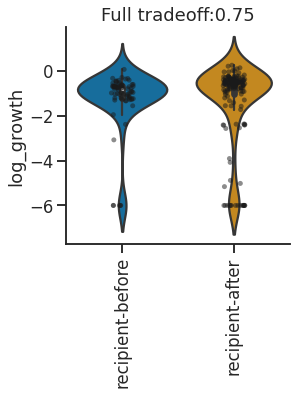

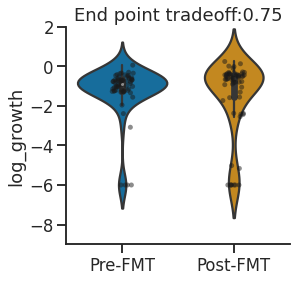

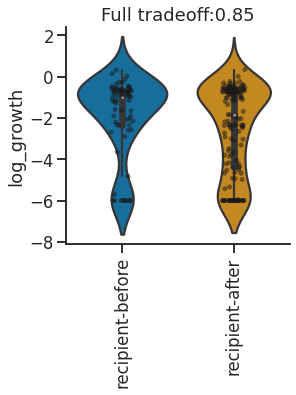

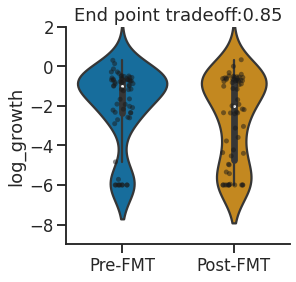

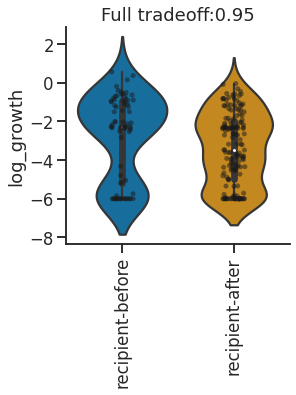

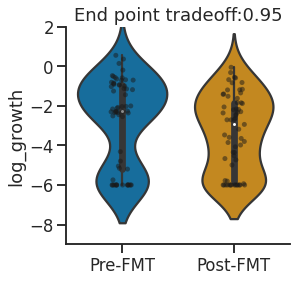

In [1193]:
from scipy.stats import wilcoxon,mannwhitneyu 
for idx,df in cdiff_growth.groupby(by='tradeoff'):
    plt.figure(figsize=(4,4,))
    sns.violinplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after'])
    sns.stripplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after'],color='k',alpha=0.5)
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.title('Full tradeoff:%s'%idx)
    x=df[df.sample_type=='recipient-before'].log_growth.values
    y=df[df.sample_type=='recipient-after'].log_growth.values
    print('%s full %s'%(idx,ttest_ind(x,y,equal_var=False).pvalue))
    res=pd.DataFrame()
    for index,df2 in df[df.sample_type!='donor'].groupby(by='subject_name'):
        if True in list(df2.sample_type.str.contains('before')) and True in list(df2.sample_type.str.contains('after')):
            df2=df2.sort_values(by='time_point_days')
            if len(df2[df2.sample_type=='recipient-before'])>1:
                before=df2[df2.sample_type=='recipient-before'].iloc[[0]]
            else:
                before=df2[df2.sample_type=='recipient-before']
            if len(df2[df2.sample_type=='recipient-after']) >1:
                after=df2[df2.sample_type=='recipient-after'].iloc[[-1]]
            else:
                after=df2[df2.sample_type=='recipient-after']
            res=pd.concat([res,before,after])
    fig, ax = plt.subplots(1,1,figsize=(4,4))
    sns.violinplot(x='sample_type',y='log_growth',data=res,order=['recipient-before','recipient-after'])
    sns.stripplot(x='sample_type',y='log_growth',data=res,order=['recipient-before','recipient-after'],color='k',alpha=0.5)
    plt.xlabel('')
    plt.ylim(-9,2)
    ax.set_xticklabels(['Pre-FMT','Post-FMT'],rotation=0)
    plt.title('End point tradeoff:%s'%idx)
    x=res[res.sample_type=='recipient-before'].log_growth.values
    y=res[res.sample_type=='recipient-after'].log_growth.values
    print('%s end point only %s'%(idx,ttest_ind(x,y,equal_var=False).pvalue))

In [1037]:
fmt_samplesxes=pd.read_pickle('12062023_natmed_fluxes_tradeoff_pfba.pkl').reset_index()
fluxes.index = pd.MultiIndex.from_tuples([tuple([str(x[0]),x[1],x[2]]) for x in fluxes[['tradeoff','sample','compartment']].values])
fluxes=fluxes.fillna(10**-6).drop(['sample','tradeoff','compartment'],axis=1)
exchanges=fluxes[fluxes.columns[['EX_' in x for x in fluxes.columns ]]]
export_flux = exchanges.copy()[[x[1] != 'community' for x in exchanges.index]]
export_flux[export_flux<=0]=10**-6
export_flux=np.log10(export_flux)
export_flux[export_flux<-6]=-6
export_flux

import_flux = exchanges.copy()[[x[1] != 'community' for x in exchanges.index]]
import_flux[import_flux >=0]=10**-6
import_flux=abs(import_flux)
import_flux=np.log10(import_flux)
import_flux=import_flux[import_flux>-6].fillna(-6)
import_flux

imprts=import_flux.reset_index()
imprts=imprts[imprts.level_2=='Clostridioides']
cdiff_rate=growth_rates[growth_rates.compartments=='Clostridioides']
cdiff_rate['tradeoff']=cdiff_rate['tradeoff'].astype(str)
cdiff_import=pd.merge(imprts,cdiff_rate,left_on=['level_0','level_1'],right_on=['tradeoff','sample'])
cdiff_import=cdiff_import.drop(['level_0','level_1','level_2'],axis=1)
cdiff_import['log_growth']=np.log10(cdiff_import.growth_rate)
cdiff_import

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/ipykernel_launcher.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,EX_12dgr180(e),EX_12dgr180_m,EX_12ppd_S(e),EX_12ppd_S_m,EX_13ppd(e),EX_13ppd_m,EX_26dap_M(e),EX_26dap_M_m,EX_2ddglcn(e),EX_2ddglcn_m,...,EX_h2o2_m,EX_icit[e],EX_icit_m,compartments,growth_rate,abundance,sample,condition,tradeoff,log_growth
0,-2.553047,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,1.350089e-01,0.100105,CAVI230300,+cdiff,0.8,-0.869638
1,-2.553047,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,1.627002e-01,0.100349,CAVI230300,+cdiff,0.8,-0.788612
2,-2.471256,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,1.350089e-01,0.100105,CAVI230300,+cdiff,0.8,-0.869638
3,-2.471256,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,1.627002e-01,0.100349,CAVI230300,+cdiff,0.8,-0.788612
4,-2.768964,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,8.214473e-02,0.100105,CAVI230300,+cdiff,0.9,-1.085420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17522,-6.000000,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,2.428293e-05,0.100297,UWIBD01P788T2,+cdiff,0.9,-4.614699
17523,-2.716653,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,2.392706e-01,0.100297,UWIBD01P788T2,+cdiff,1.0,-0.621111
17524,-6.000000,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,1.775639e-13,0.100422,UWIBD01P788T3,+cdiff,0.8,-12.750645
17525,-6.000000,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,...,-6.0,-6.0,-6.0,Clostridioides,4.936613e-12,0.100422,UWIBD01P788T3,+cdiff,0.9,-11.306571


/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()
/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


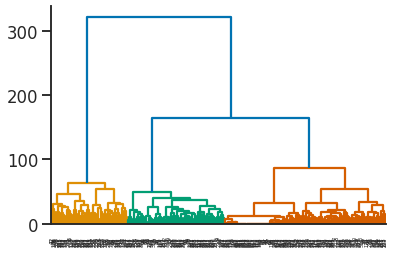

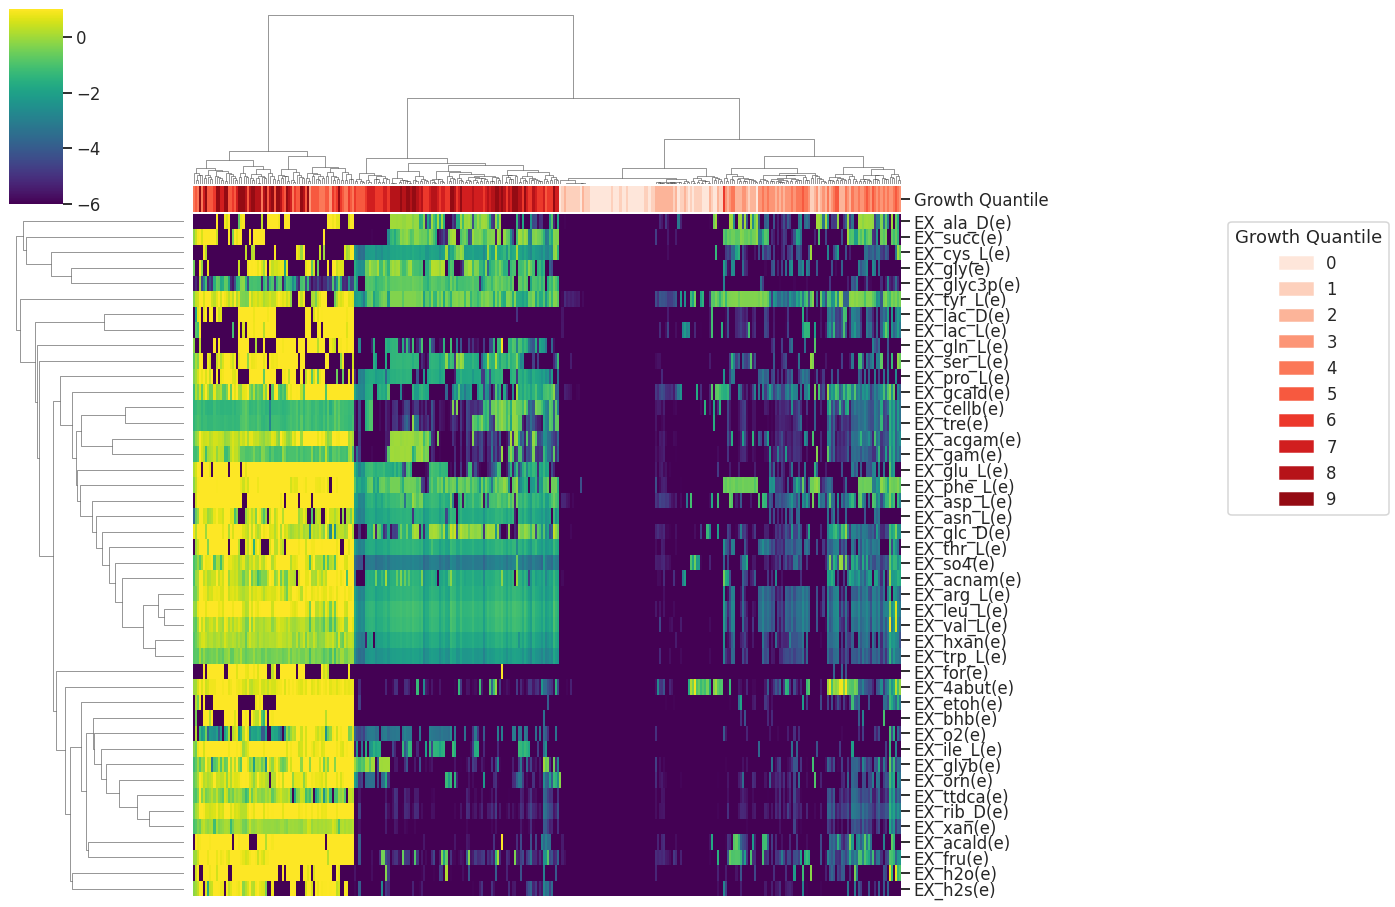

In [1183]:
hits=['EX_4abut(e)', 'EX_acald(e)', 'EX_acnam(e)', 'EX_ala_D(e)',
       'EX_arg_L(e)', 'EX_asn_L(e)', 'EX_asp_L(e)', 'EX_cellb(e)',
       'EX_cys_L(e)', 'EX_fru(e)', 'EX_gcald(e)', 'EX_glc_D(e)', 'EX_glu_L(e)',
       'EX_gly(e)', 'EX_glyc3p(e)', 'EX_h2o(e)', 'EX_hxan(e)', 'EX_ile_L(e)',
       'EX_leu_L(e)', 'EX_man(e)', 'EX_met_L(e)', 'EX_orn(e)', 'EX_phe_L(e)',
       'EX_pi(e)', 'EX_pro_L(e)', 'EX_ser_L(e)', 'EX_succ(e)', 'EX_thr_L(e)',
       'EX_tre(e)', 'EX_ura(e)', 'EX_val_L(e)']

df = cdiff_import[(cdiff_import['sample'].isin(cdiff_growth['sample'].unique()))&(cdiff_import.tradeoff=='0.9')]
df.index=df['sample']
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
import matplotlib.patches as mpatches
cols=df.columns[~df.columns.str.contains('_m')]

n=10
df['Growth Quantile']=pd.qcut(df.log_growth,n,labels=False)
colors=sns.color_palette('Reds',n)
cmap = {}
i = 0
for group in sorted(df['Growth Quantile'].unique()):
    cmap[group] = colors[i]
    i+=1
#Use color dictionary to map color to speces column (provides color of each data point)
col_colors=df['Growth Quantile'].copy()
col_colors=col_colors.map(cmap)

idx=df[cols].iloc[:,:-8].var()[df[cols].iloc[:,:-8].var()>=4.5].index
max_d =150
X=df[idx]
Z = linkage(X, 'ward')
dendro = dendrogram(Z,color_threshold=max_d)
clusters = fcluster(Z, max_d, criterion='distance')
#colors=sns.color_palette('colorblind',len(pd.unique(clusters)))
#cmap={i:colors[i-1] for i in pd.unique(clusters)}


clust=sns.clustermap(df[idx].T,cmap='viridis',vmin=-6,vmax=1,figsize=(15,15),col_colors=col_colors,yticklabels=1,col_linkage=Z)
order=[x.get_text() for x in clust.ax_heatmap.get_xticklabels()]
clust.ax_heatmap.set_ylabel('')
clust.ax_heatmap.set_xlabel('')
clust.ax_heatmap.set_xticks([])
#Create custom legend to include in plot 
handles = []
labels = sorted(df['Growth Quantile'].unique())
for i in range(len(sorted(labels))):
    patch = mpatches.Patch(color=colors[i],label=labels[i])
    handles.append(patch)  
clust.ax_heatmap.legend(handles=handles,bbox_to_anchor=(1.45,1),loc=2,title='Growth Quantile')
order=clust.data2d.columns
#plt.savefig('Cdiff-FMT-ImportHeatmap-metagenome-v2.pdf',bbox_inches='tight')

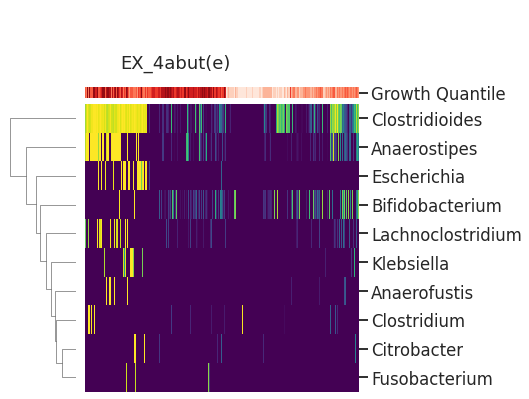

<Figure size 432x288 with 0 Axes>

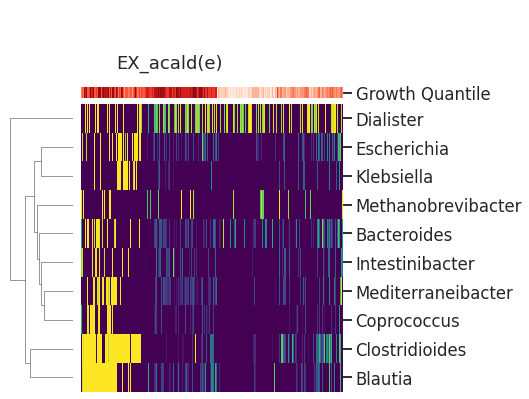

<Figure size 432x288 with 0 Axes>

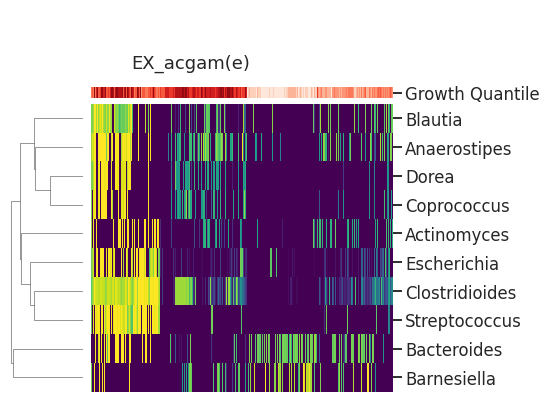

<Figure size 432x288 with 0 Axes>

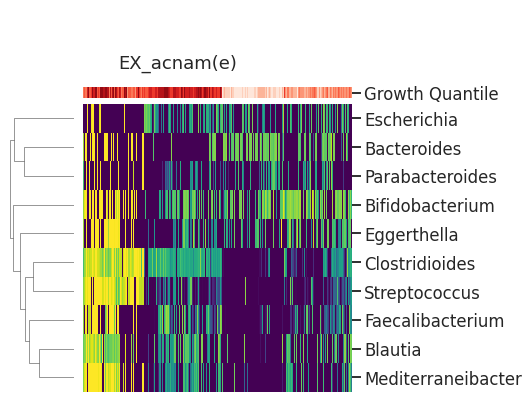

<Figure size 432x288 with 0 Axes>

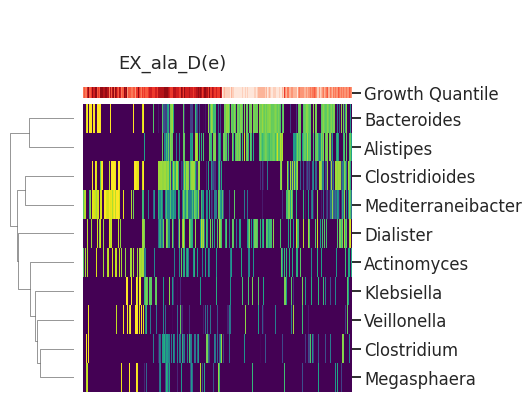

<Figure size 432x288 with 0 Axes>

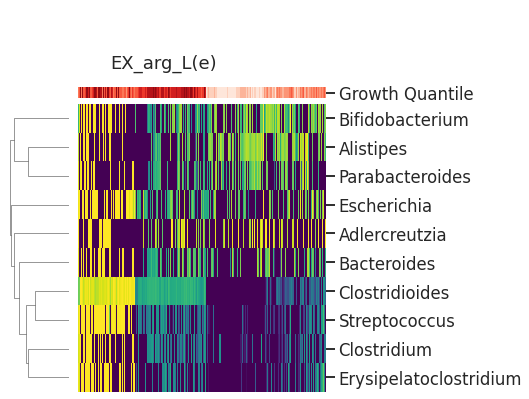

<Figure size 432x288 with 0 Axes>

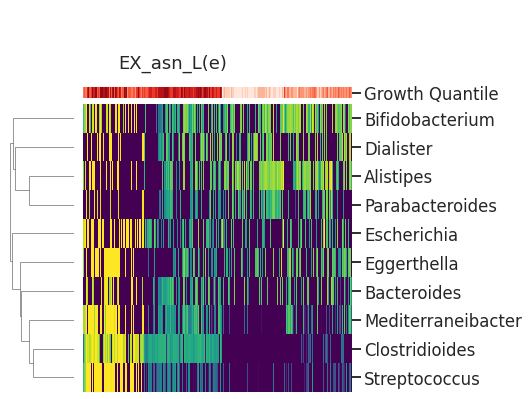

<Figure size 432x288 with 0 Axes>

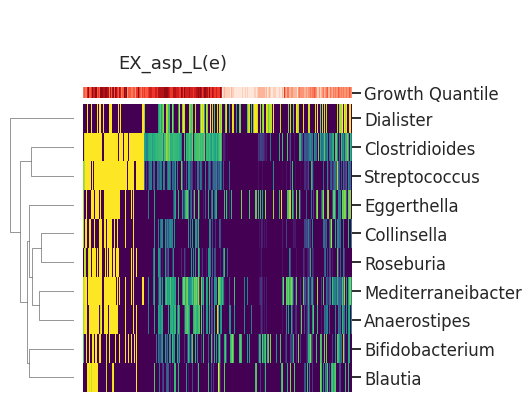

<Figure size 432x288 with 0 Axes>

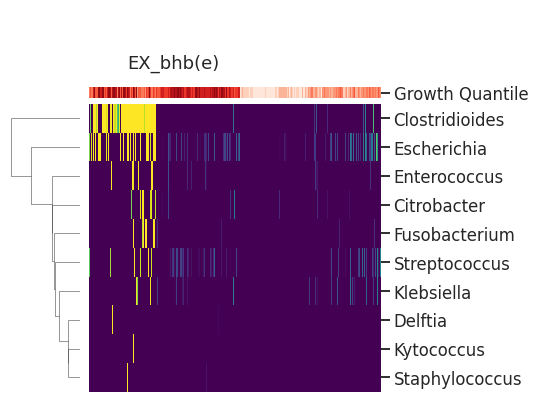

<Figure size 432x288 with 0 Axes>

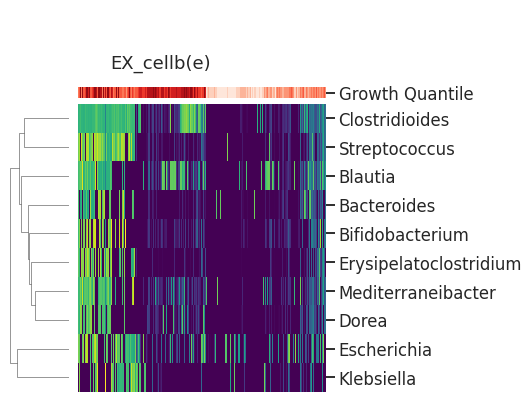

<Figure size 432x288 with 0 Axes>

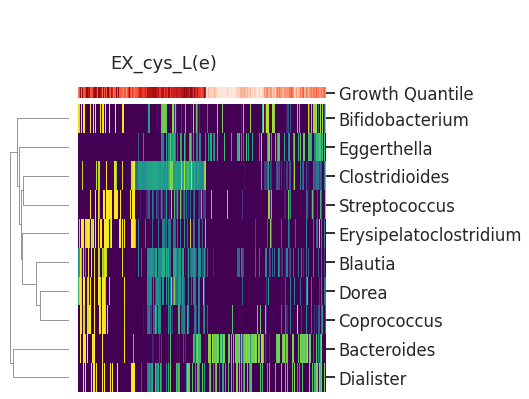

<Figure size 432x288 with 0 Axes>

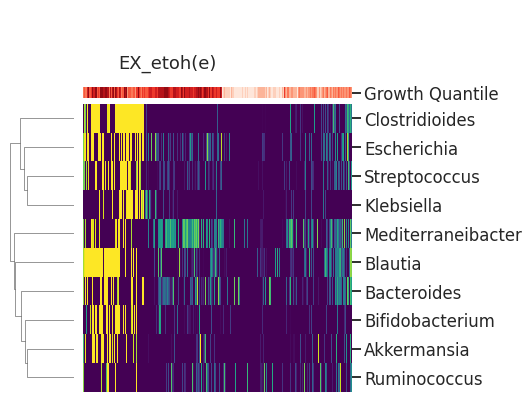

<Figure size 432x288 with 0 Axes>

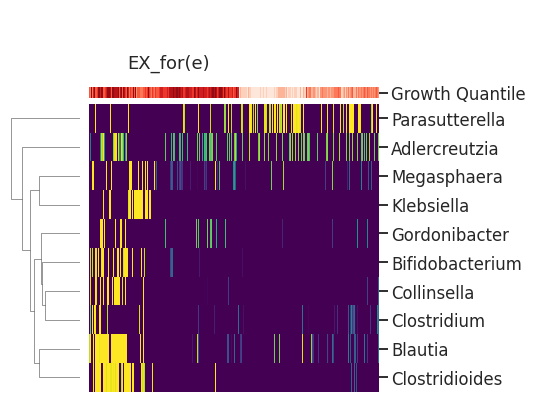

<Figure size 432x288 with 0 Axes>

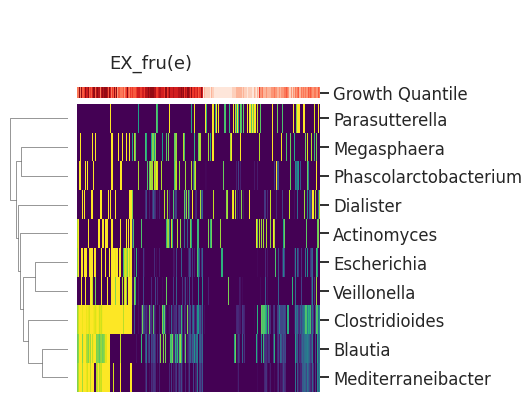

<Figure size 432x288 with 0 Axes>

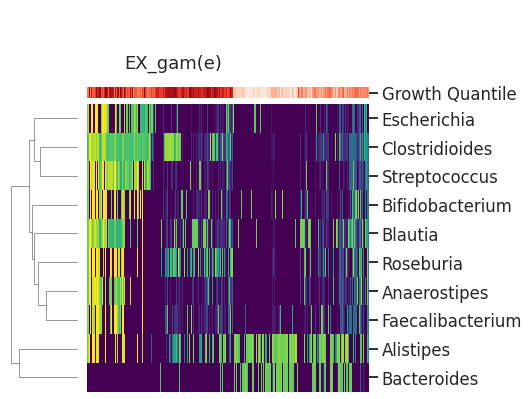

<Figure size 432x288 with 0 Axes>

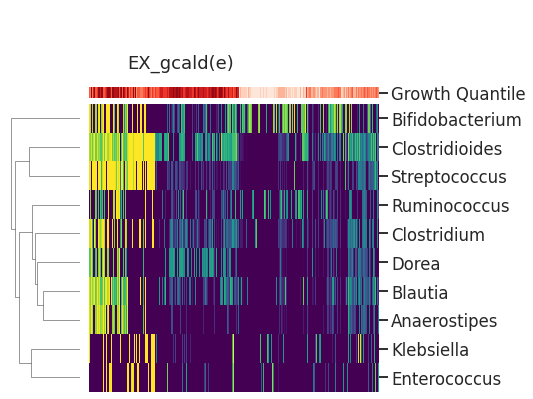

<Figure size 432x288 with 0 Axes>

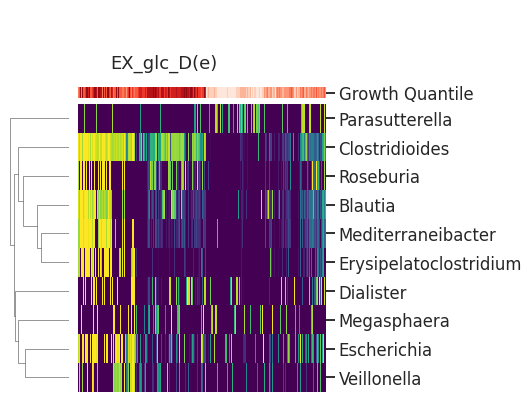

<Figure size 432x288 with 0 Axes>

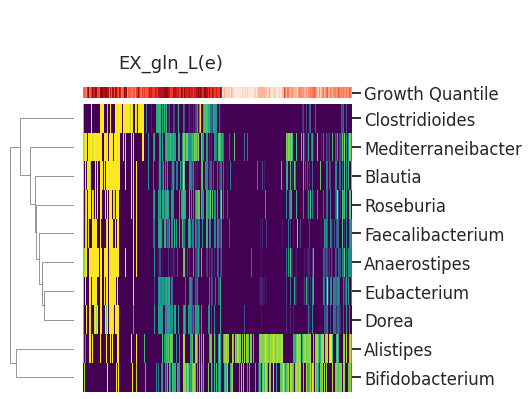

<Figure size 432x288 with 0 Axes>

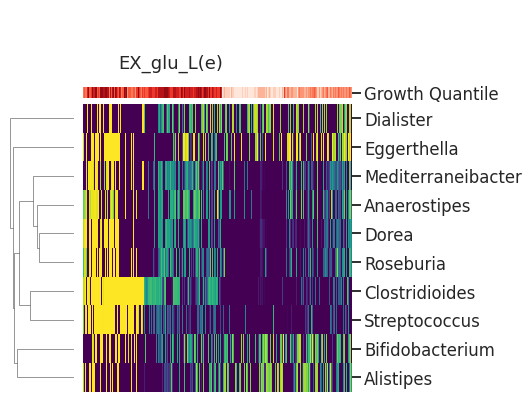

<Figure size 432x288 with 0 Axes>

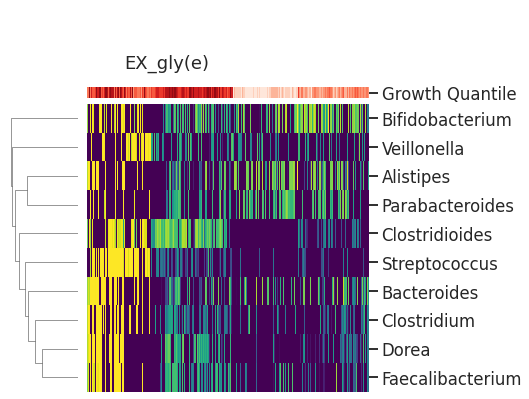

<Figure size 432x288 with 0 Axes>

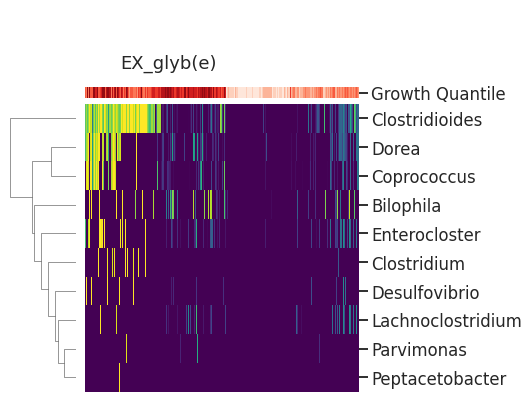

<Figure size 432x288 with 0 Axes>

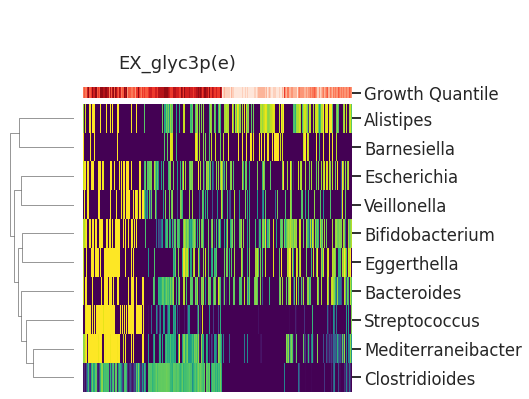

<Figure size 432x288 with 0 Axes>

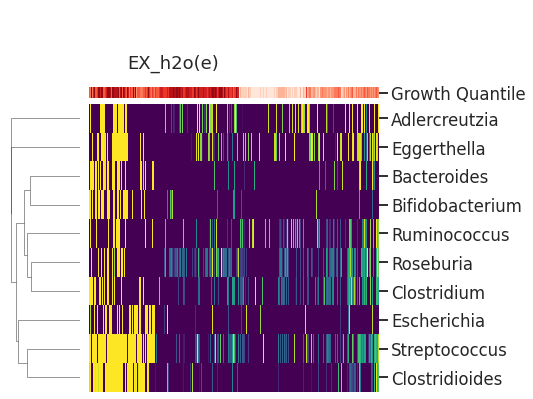

<Figure size 432x288 with 0 Axes>

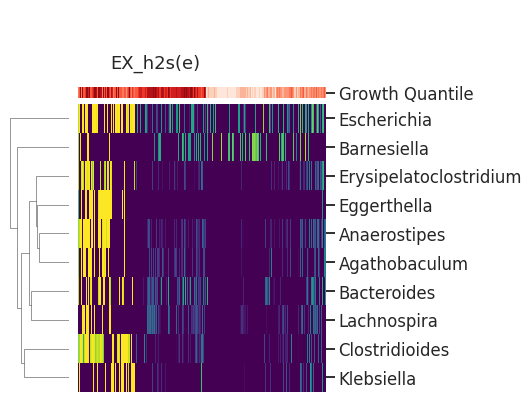

<Figure size 432x288 with 0 Axes>

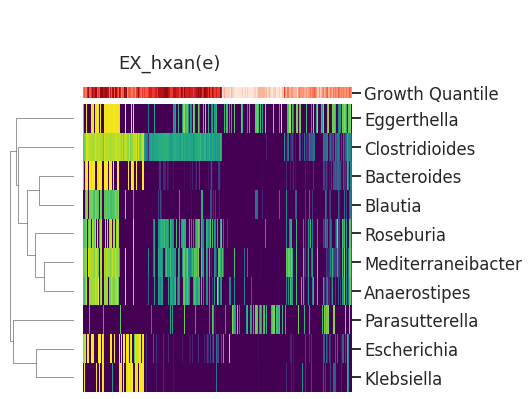

<Figure size 432x288 with 0 Axes>

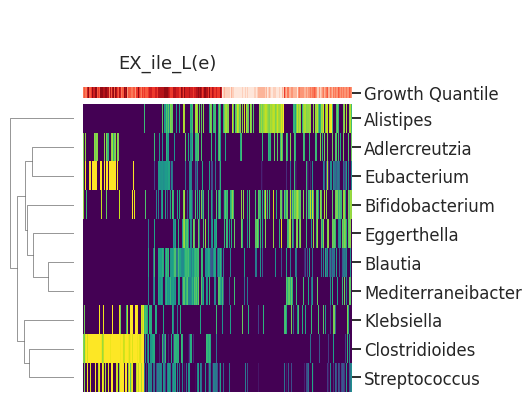

<Figure size 432x288 with 0 Axes>

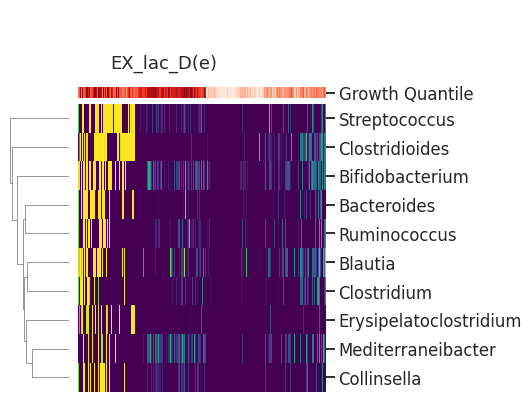

<Figure size 432x288 with 0 Axes>

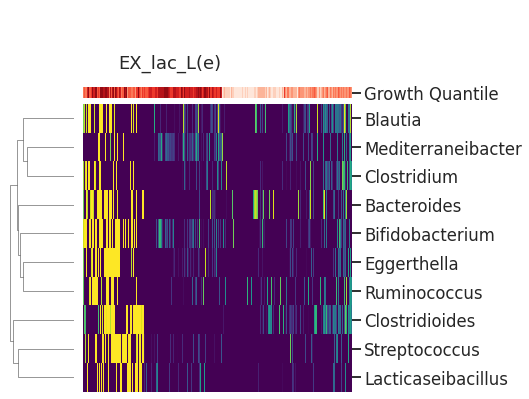

<Figure size 432x288 with 0 Axes>

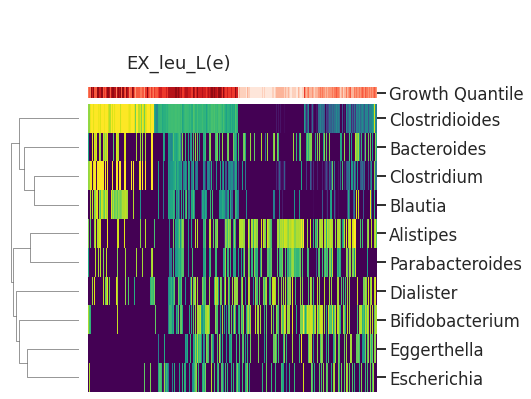

<Figure size 432x288 with 0 Axes>

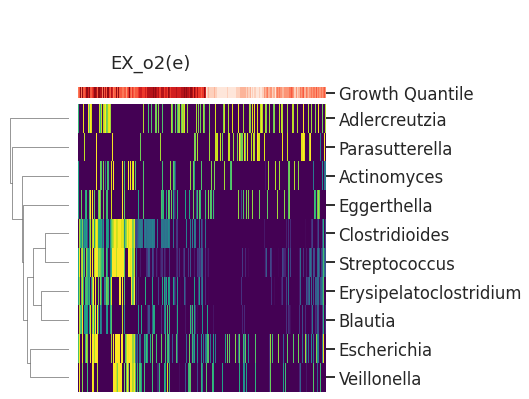

<Figure size 432x288 with 0 Axes>

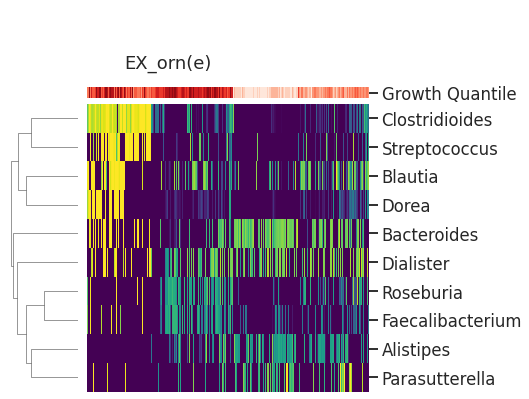

<Figure size 432x288 with 0 Axes>

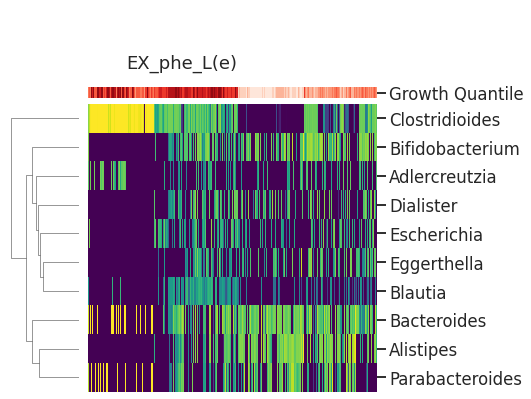

<Figure size 432x288 with 0 Axes>

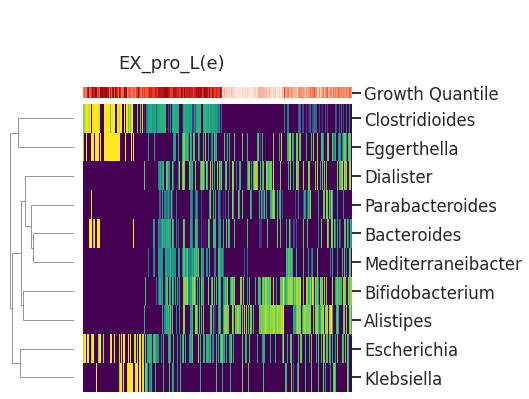

<Figure size 432x288 with 0 Axes>

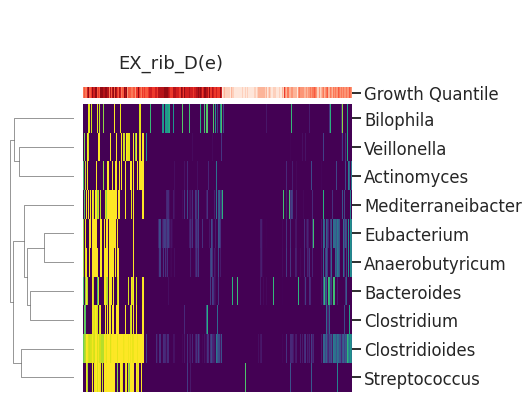

<Figure size 432x288 with 0 Axes>

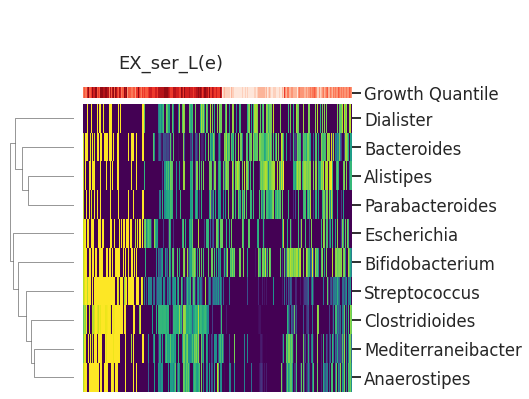

<Figure size 432x288 with 0 Axes>

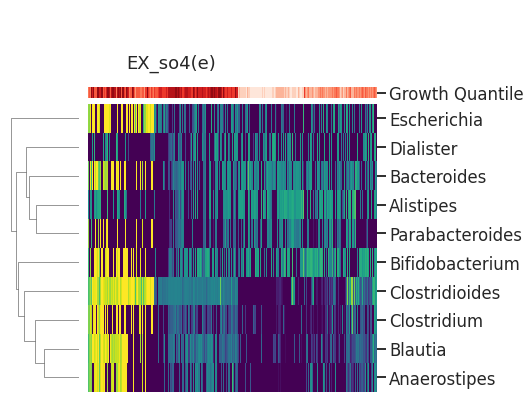

<Figure size 432x288 with 0 Axes>

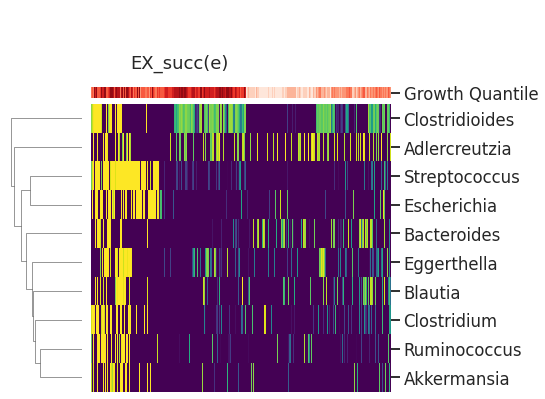

<Figure size 432x288 with 0 Axes>

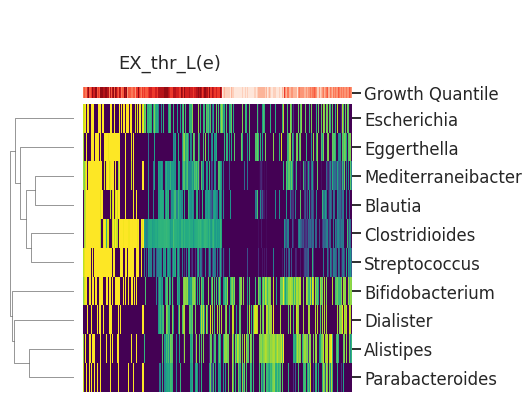

<Figure size 432x288 with 0 Axes>

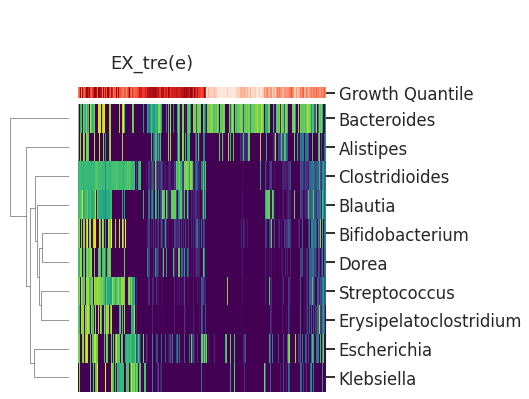

<Figure size 432x288 with 0 Axes>

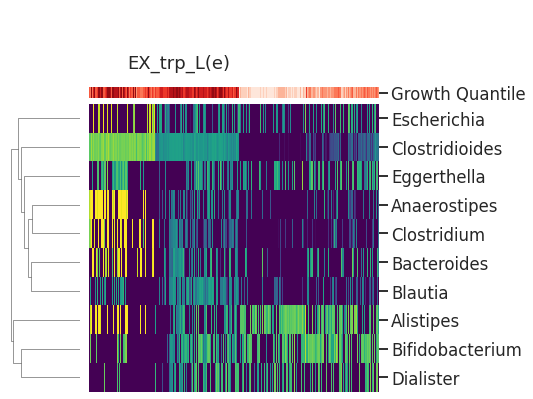

<Figure size 432x288 with 0 Axes>

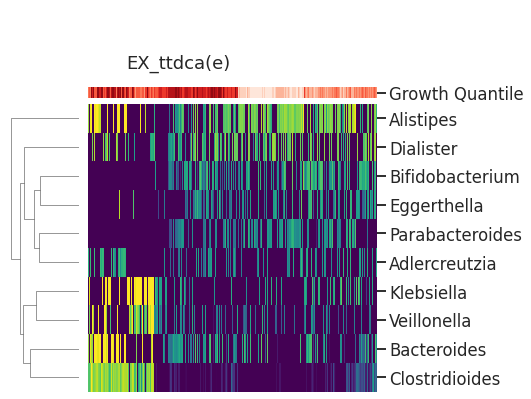

<Figure size 432x288 with 0 Axes>

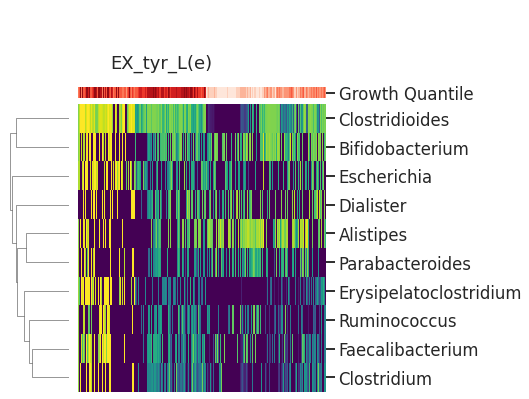

<Figure size 432x288 with 0 Axes>

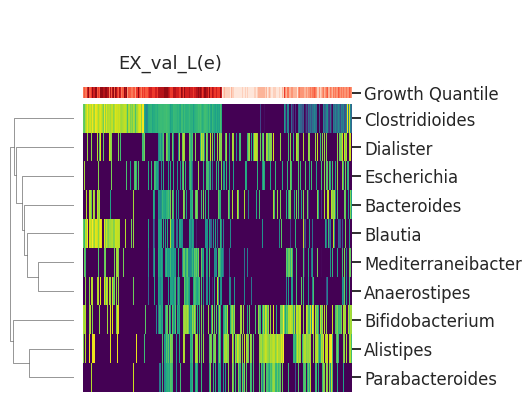

<Figure size 432x288 with 0 Axes>

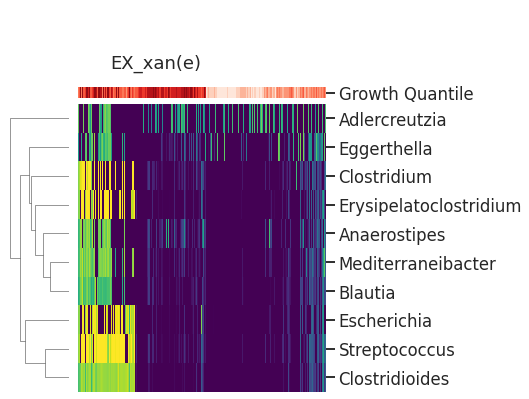

<Figure size 432x288 with 0 Axes>

In [1105]:
smps=df['sample'].values
for flx in idx:
    com_flx=import_flux[flx].loc['0.9']
    com_flux=com_flx.reset_index()
    ix=com_flux[['level_0','level_1']].drop_duplicates().index
    com_flux=com_flux.loc[ix]
    com_flux=com_flux.pivot(index='level_0',columns='level_1',values=flx)
    com_flux=com_flux.loc[smps]
    com_flux[com_flux<-6]=-6
    com_flux=com_flux.fillna(-6)
    #com_flux['cluster']=clusters
    #com_flux=com_flux=com_flux.sort_values(by='cluster')
    #com_flux.drop('cluster',inplace=True,axis=1)
    genera=com_flux.mean().sort_values(ascending=False).iloc[:10].index
    #cols=com_flux.columns[com_flux.mean()>-5]
    #if len(cols) < 3:
    #    continue
    clust=sns.clustermap(com_flux.loc[order,genera].T,cmap='viridis',vmin=-6,vmax=1,figsize=(8,8),col_linkage=Z,col_colors=col_colors,col_cluster=False)
    clust.ax_heatmap.set_ylabel('')
    clust.ax_heatmap.set_xlabel('')
    clust.ax_heatmap.set_xticks([])
    clust.cax.set_visible(False)
    clust.ax_heatmap.text(45,-1.25,flx)
    plt.savefig('Comm-import-%s-v2.pdf'%(flx),bbox_inches='tight')
    plt.show()
    plt.clf()

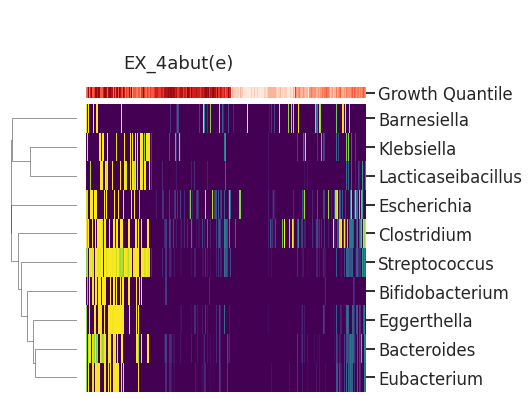

<Figure size 432x288 with 0 Axes>

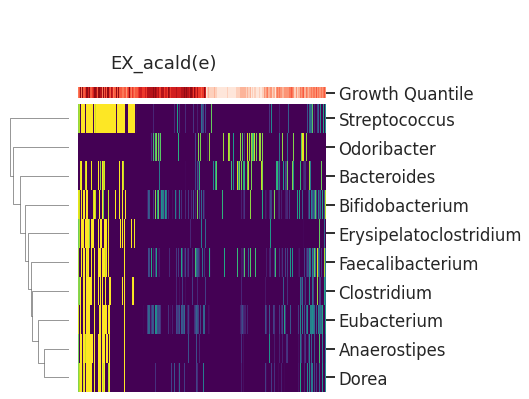

<Figure size 432x288 with 0 Axes>

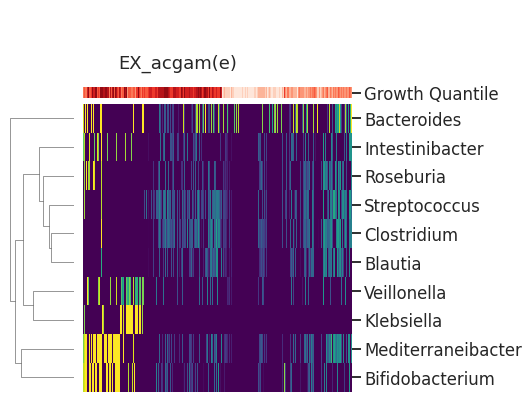

<Figure size 432x288 with 0 Axes>

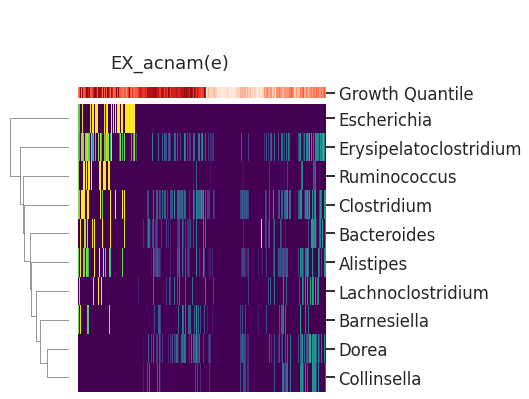

<Figure size 432x288 with 0 Axes>

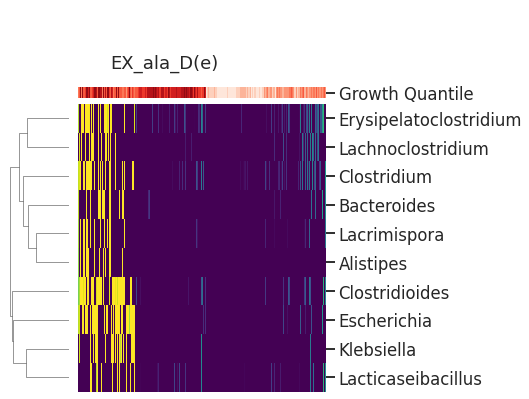

<Figure size 432x288 with 0 Axes>

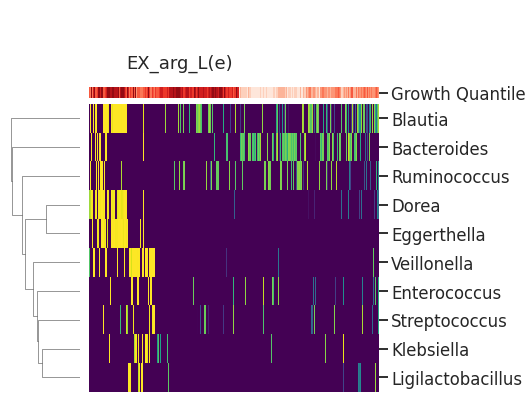

<Figure size 432x288 with 0 Axes>

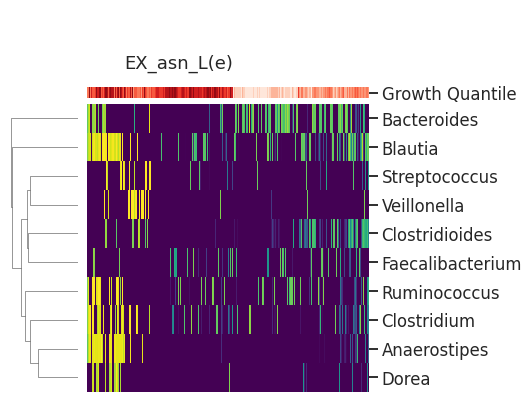

<Figure size 432x288 with 0 Axes>

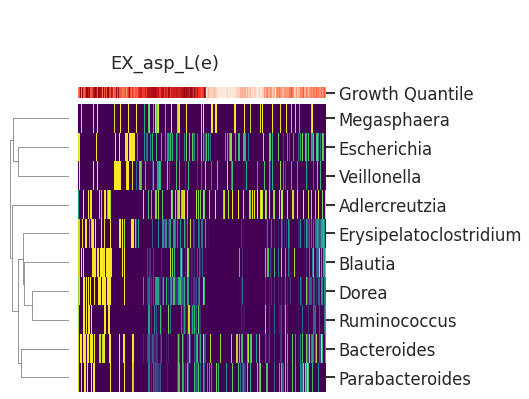

<Figure size 432x288 with 0 Axes>

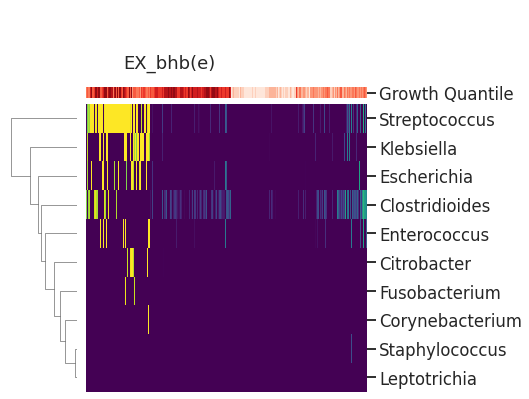

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/seaborn/matrix.py:709: UserWarning: Attempting to set identical left == right == 0 results in singular transformations; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


<Figure size 432x288 with 0 Axes>

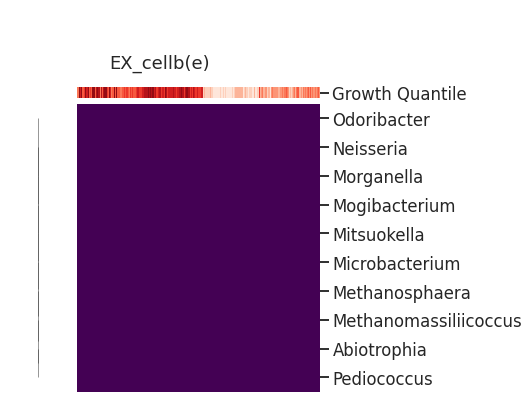

<Figure size 432x288 with 0 Axes>

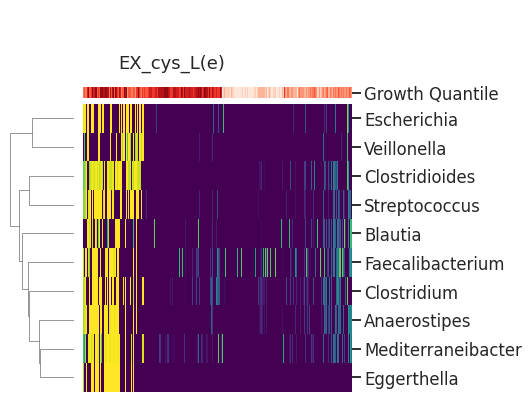

<Figure size 432x288 with 0 Axes>

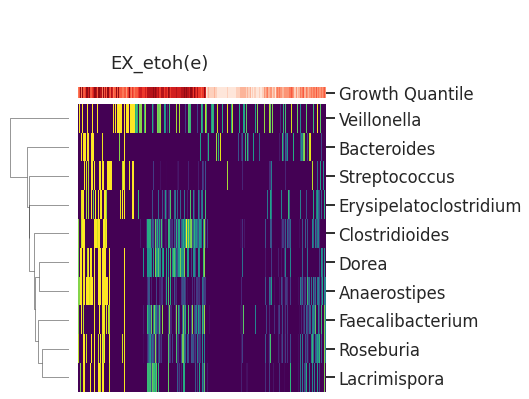

<Figure size 432x288 with 0 Axes>

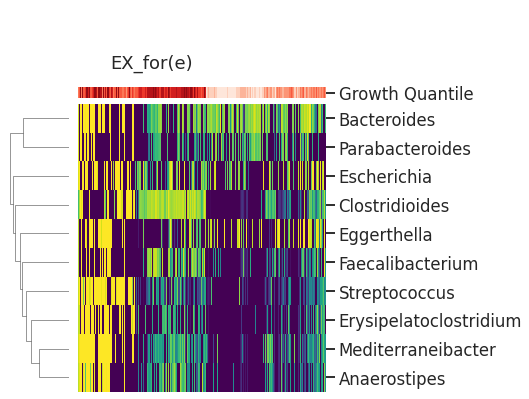

<Figure size 432x288 with 0 Axes>

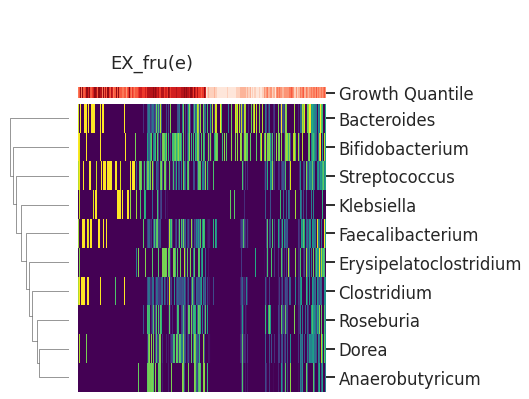

<Figure size 432x288 with 0 Axes>

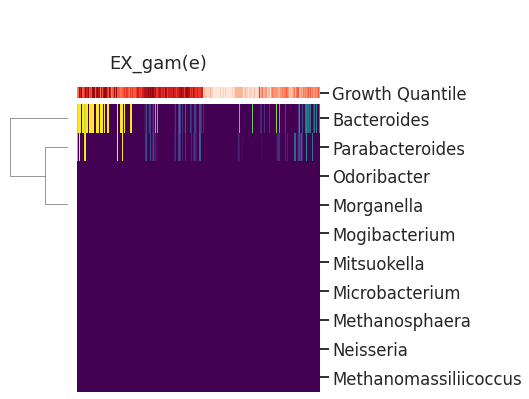

<Figure size 432x288 with 0 Axes>

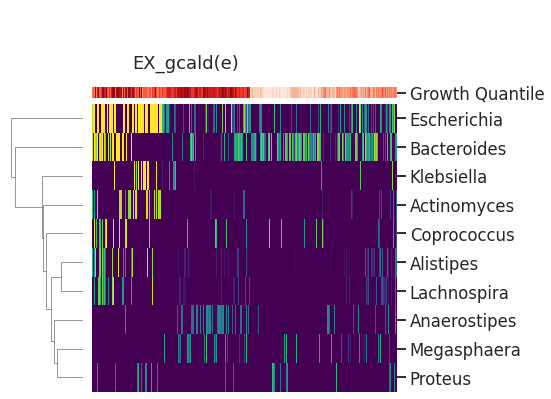

<Figure size 432x288 with 0 Axes>

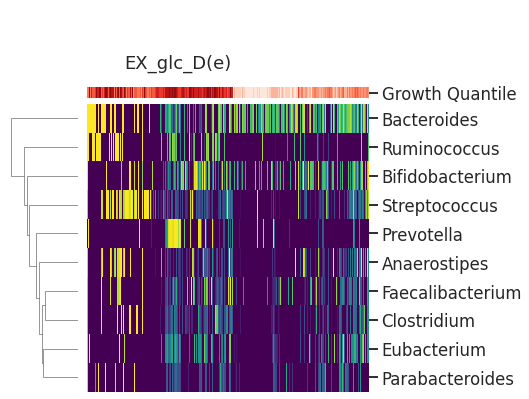

<Figure size 432x288 with 0 Axes>

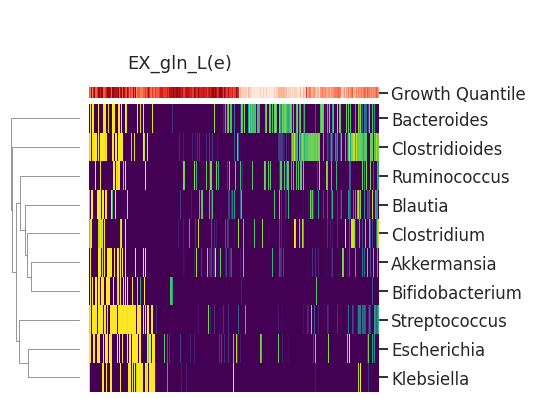

<Figure size 432x288 with 0 Axes>

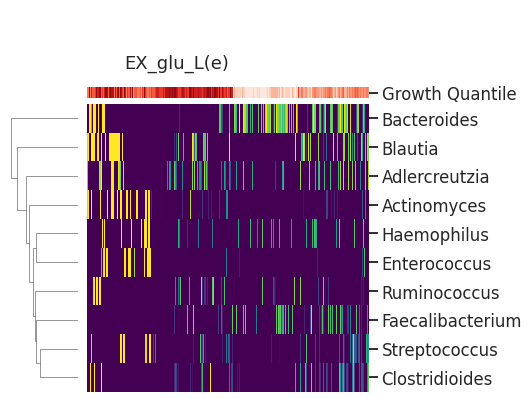

<Figure size 432x288 with 0 Axes>

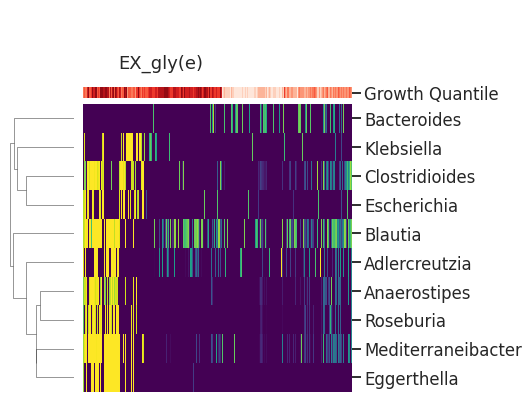

<Figure size 432x288 with 0 Axes>

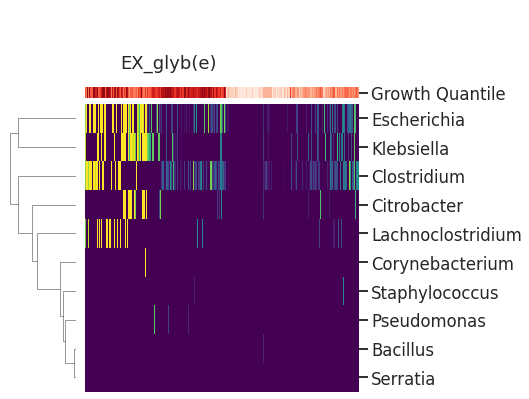

<Figure size 432x288 with 0 Axes>

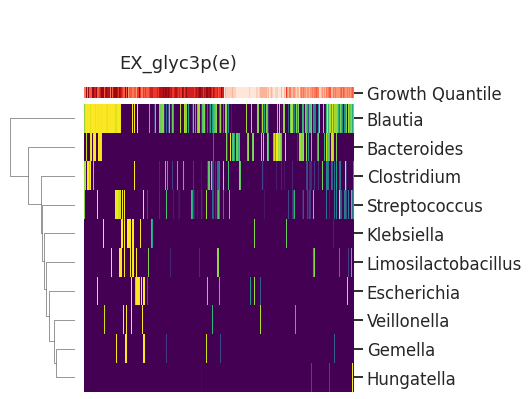

<Figure size 432x288 with 0 Axes>

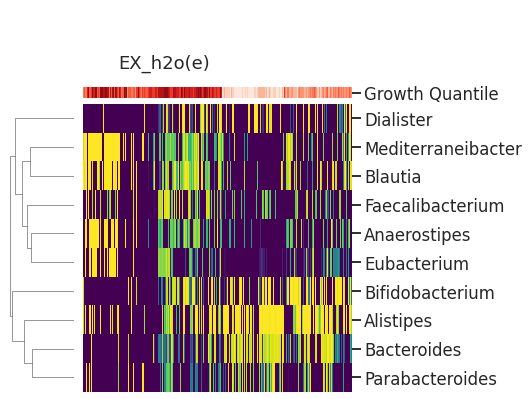

<Figure size 432x288 with 0 Axes>

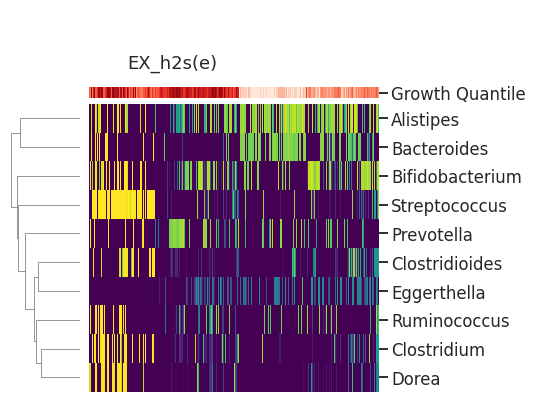

<Figure size 432x288 with 0 Axes>

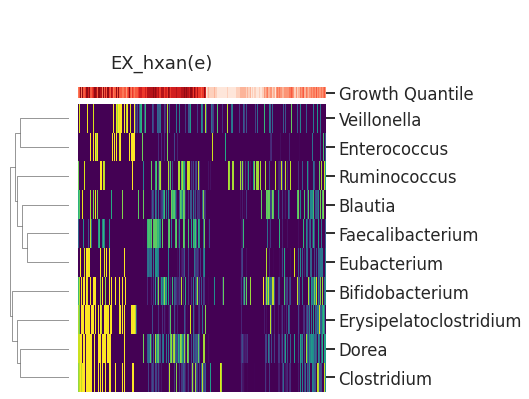

<Figure size 432x288 with 0 Axes>

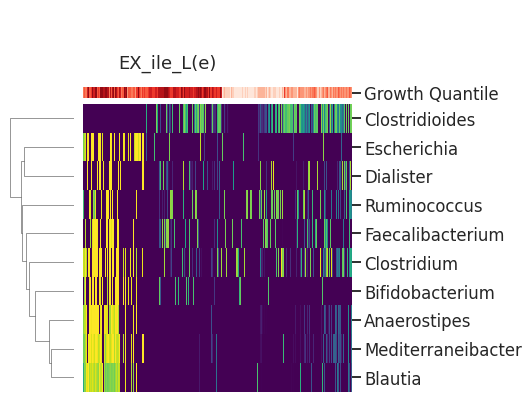

<Figure size 432x288 with 0 Axes>

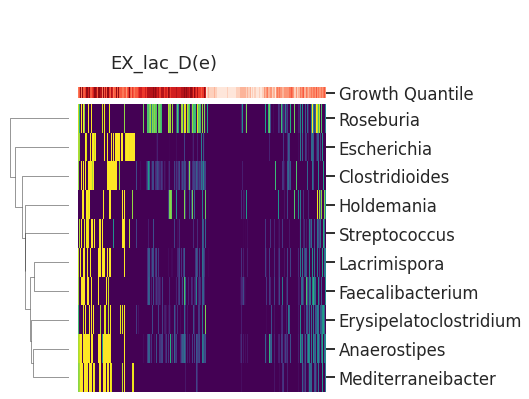

<Figure size 432x288 with 0 Axes>

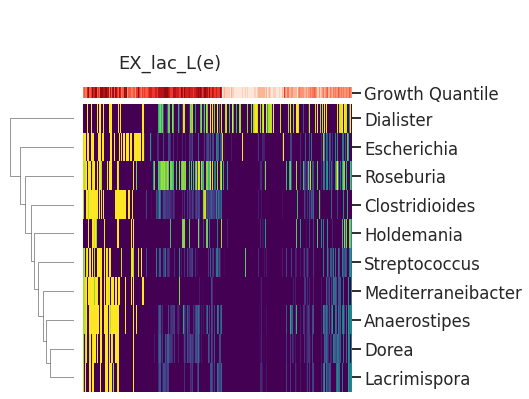

<Figure size 432x288 with 0 Axes>

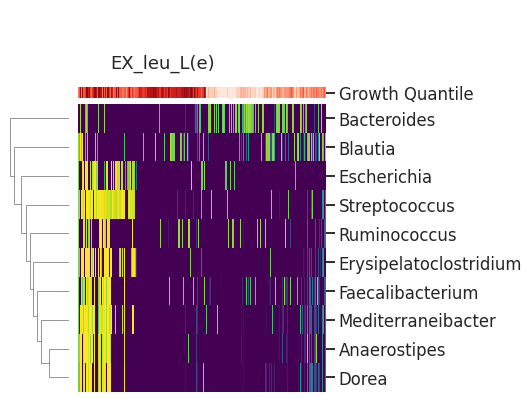

<Figure size 432x288 with 0 Axes>

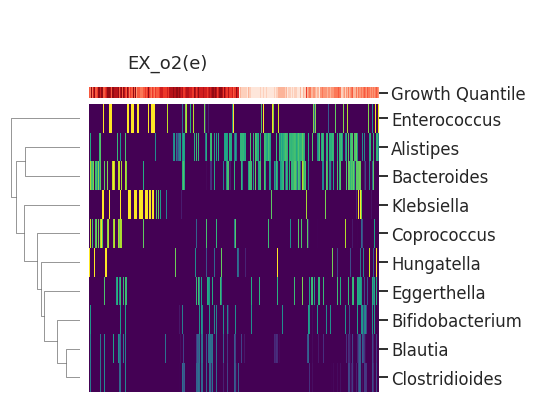

<Figure size 432x288 with 0 Axes>

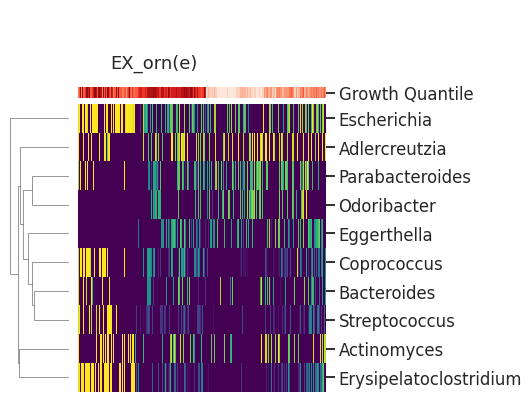

<Figure size 432x288 with 0 Axes>

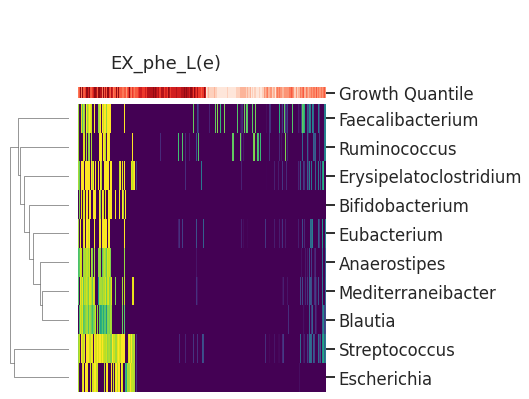

<Figure size 432x288 with 0 Axes>

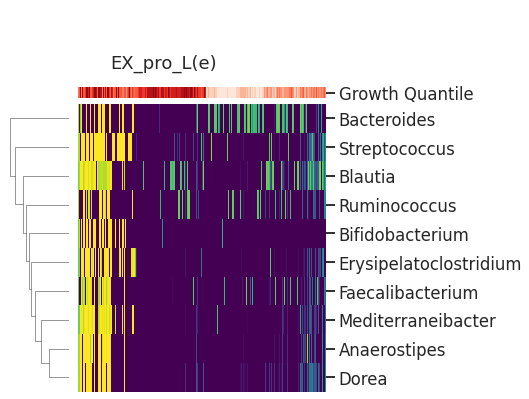

<Figure size 432x288 with 0 Axes>

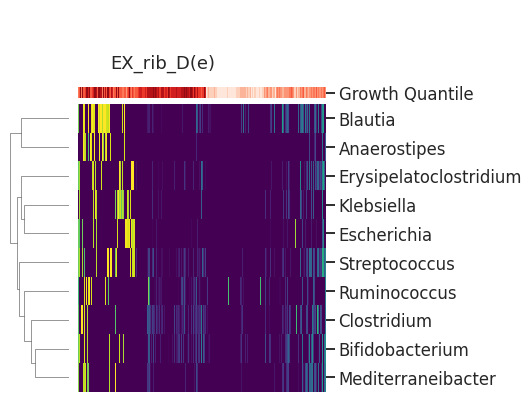

<Figure size 432x288 with 0 Axes>

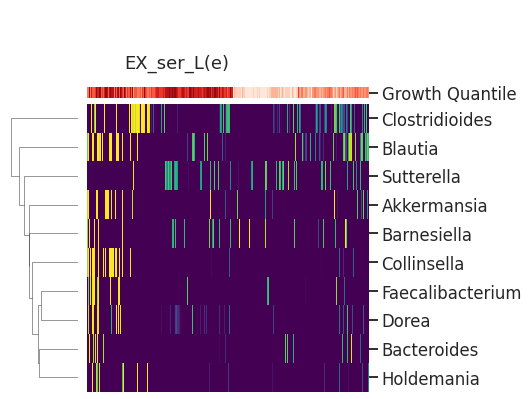

<Figure size 432x288 with 0 Axes>

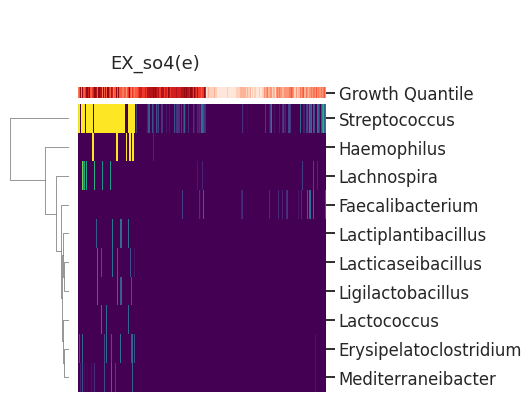

<Figure size 432x288 with 0 Axes>

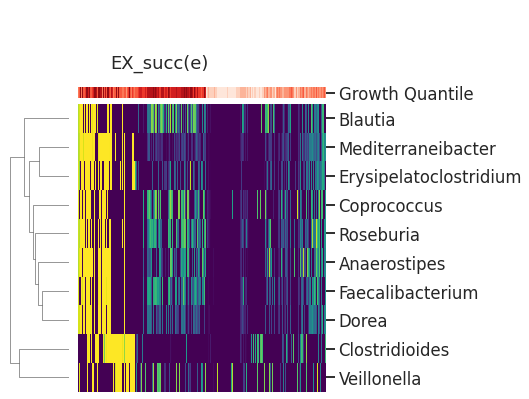

<Figure size 432x288 with 0 Axes>

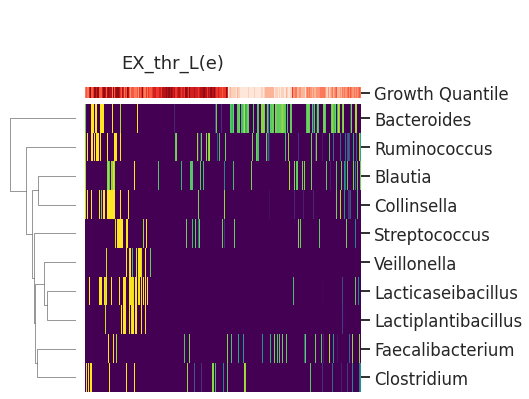

<Figure size 432x288 with 0 Axes>

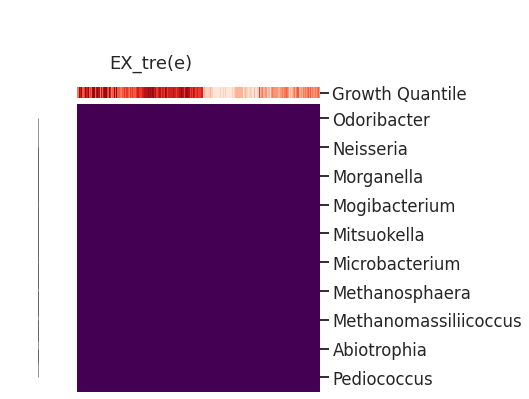

<Figure size 432x288 with 0 Axes>

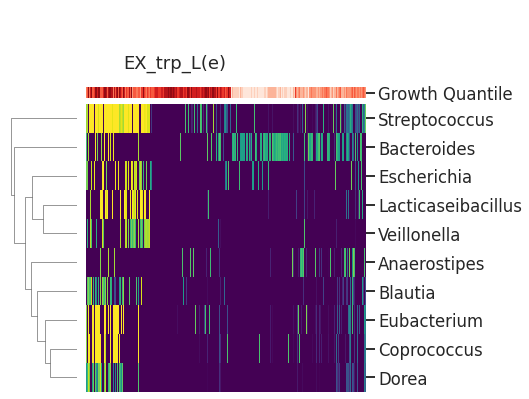

<Figure size 432x288 with 0 Axes>

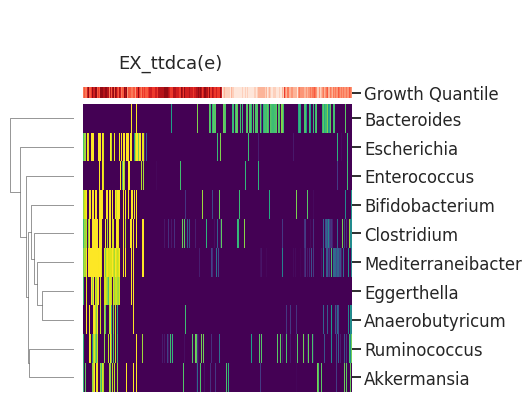

<Figure size 432x288 with 0 Axes>

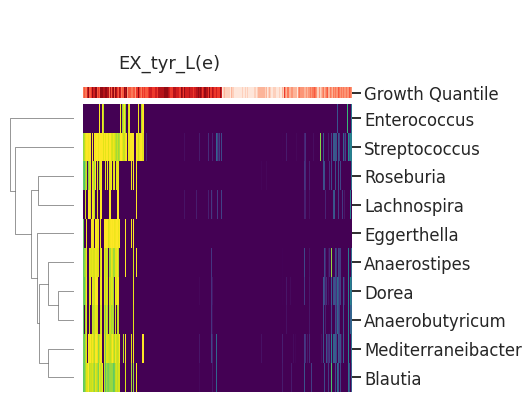

<Figure size 432x288 with 0 Axes>

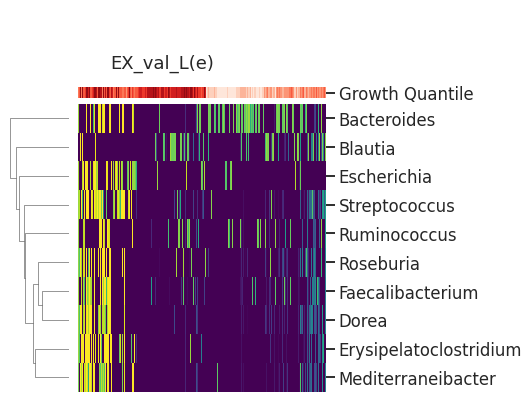

<Figure size 432x288 with 0 Axes>

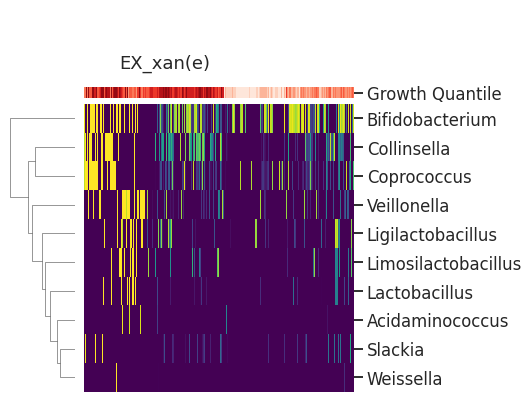

<Figure size 432x288 with 0 Axes>

In [1106]:
for flx in idx:
    com_flx=export_flux[flx].loc['0.9']
    com_flux=com_flx.reset_index()
    ix=com_flux[['level_0','level_1']].drop_duplicates().index
    com_flux=com_flux.loc[ix]
    com_flux=com_flux.pivot(index='level_0',columns='level_1',values=flx)
    com_flux=com_flux.loc[smps]
    com_flux[com_flux<-6]=-6
    com_flux=com_flux.fillna(-6)
    #com_flux['cluster']=clusters
    #com_flux=com_flux=com_flux.sort_values(by='cluster')
    #com_flux.drop('cluster',inplace=True,axis=1)
    genera=com_flux.mean().sort_values(ascending=False).iloc[:10].index
    #cols=com_flux.columns[com_flux.mean()>-5]
    #if len(cols) < 3:
    #    continue
    clust=sns.clustermap(com_flux.loc[order,genera].T,cmap='viridis',vmin=-6,vmax=1,figsize=(8,8),col_linkage=Z,col_colors=col_colors,col_cluster=False)
    clust.ax_heatmap.set_ylabel('')
    clust.ax_heatmap.set_xlabel('')
    clust.ax_heatmap.set_xticks([])
    clust.cax.set_visible(False)
    clust.ax_heatmap.text(45,-1.25,flx)
    plt.savefig('Comm-export-%s-v2.pdf'%(flx),bbox_inches='tight')
    plt.show()
    plt.clf()

In [1184]:
set(idx)-set(hits)

{'EX_acgam(e)',
 'EX_bhb(e)',
 'EX_etoh(e)',
 'EX_for(e)',
 'EX_gam(e)',
 'EX_gln_L(e)',
 'EX_glyb(e)',
 'EX_h2s(e)',
 'EX_lac_D(e)',
 'EX_lac_L(e)',
 'EX_o2(e)',
 'EX_rib_D(e)',
 'EX_so4(e)',
 'EX_trp_L(e)',
 'EX_ttdca(e)',
 'EX_tyr_L(e)',
 'EX_xan(e)'}

In [1192]:
len(set(hits)-set(idx))

4

In [1190]:
len(hits)

31

In [1088]:
for x in com_flux.columns:
    print(x)

Abiotrophia
Acidaminococcus
Actinomyces
Adlercreutzia
Agathobaculum
Akkermansia
Alistipes
Alloprevotella
Amedibacillus
Anaerobutyricum
Anaerococcus
Anaerofustis
Anaerostipes
Anaerotruncus
Arcanobacterium
Atlantibacter
Atopobium
Bacillus
Bacteroides
Barnesiella
Bifidobacterium
Bilophila
Blautia
Brachyspira
Butyricicoccus
Butyricimonas
Butyrivibrio
Campylobacter
Capnocytophaga
Catenibacterium
Citrobacter
Cloacibacillus
Clostridioides
Clostridium
Collinsella
Comamonas
Coprobacillus
Coprococcus
Corynebacterium
Cronobacter
Cutibacterium
Delftia
Desulfovibrio
Dialister
Dorea
Dysgonomonas
Eggerthella
Eikenella
Enterobacter
Enterocloster
Enterococcus
Erysipelatoclostridium
Escherichia
Eubacterium
Faecalibacterium
Faecalicoccus
Faecalitalea
Finegoldia
Flavonifractor
Fusobacterium
Gemella
Gordonibacter
Granulicatella
Haemophilus
Hafnia
Helicobacter
Holdemanella
Holdemania
Hungatella
Intestinibacter
Klebsiella
Kluyvera
Kytococcus
Lachnoclostridium
Lachnospira
Lacrimispora
Lacticaseibacillus
Lacti

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


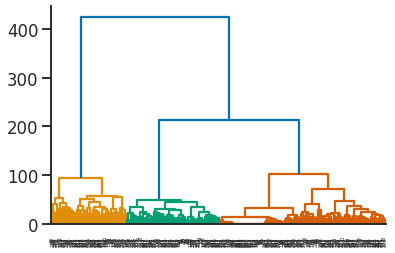

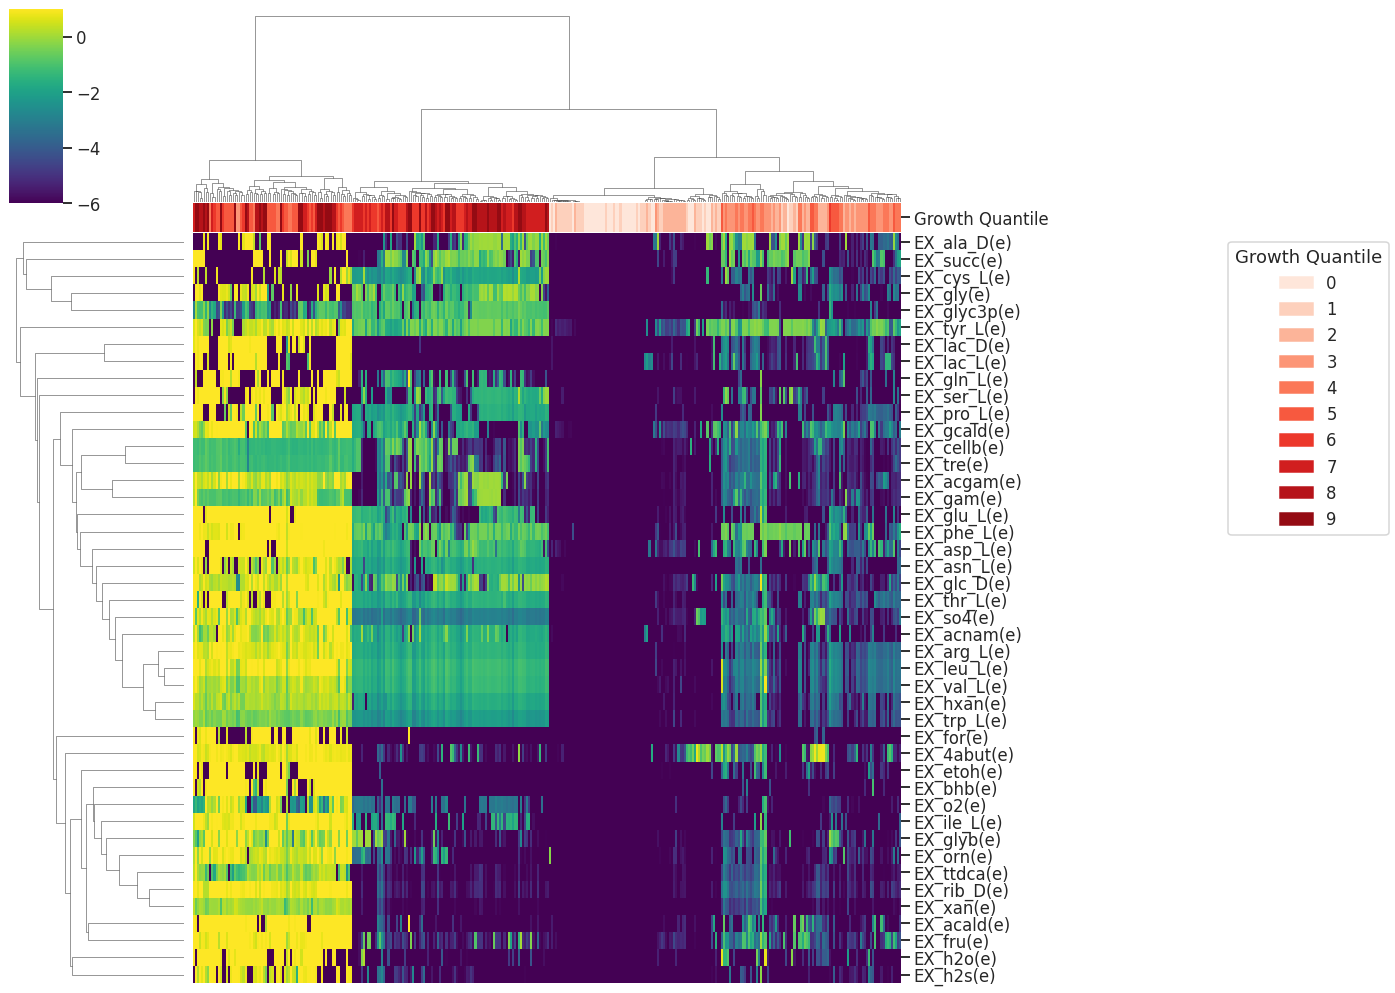

In [807]:
df = cdiff_import[(cdiff_import['sample'].isin(cdiff_growth['sample'].unique()))&(cdiff_import.tradeoff=='0.9')]

from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
import matplotlib.patches as mpatches
cols=df.columns[~df.columns.str.contains('_m')]
max_d =150
X=df[cols].iloc[:,:-8]
Z = linkage(X, 'ward')
dendro = dendrogram(Z,color_threshold=max_d)
clusters = fcluster(Z, max_d, criterion='distance')
colors=sns.color_palette('colorblind',len(pd.unique(clusters)))
cmap={i:colors[i-1] for i in pd.unique(clusters)}

n=10
df['Growth Quantile']=pd.qcut(df.log_growth,n,labels=False)
colors=sns.color_palette('Reds',n)
cmap = {}
i = 0
for group in sorted(df['Growth Quantile'].unique()):
    cmap[group] = colors[i]
    i+=1
#Use color dictionary to map color to speces column (provides color of each data point)
col_colors=df['Growth Quantile'].copy()
col_colors=col_colors.map(cmap)
idx=df[cols].iloc[:,:-8].var()[df[cols].iloc[:,:-8].var()>=4.5].index
hits=idx
clust=sns.clustermap(df[idx].T,cmap='viridis',vmin=-6,vmax=1,figsize=(15,15),col_colors=col_colors,yticklabels=1,col_linkage=Z)
order=[x.get_text() for x in clust.ax_heatmap.get_xticklabels()]
clust.ax_heatmap.set_ylabel('')
clust.ax_heatmap.set_xlabel('')
clust.ax_heatmap.set_xticks([])
#Create custom legend to include in plot 
handles = []
labels = sorted(df['Growth Quantile'].unique())
for i in range(len(sorted(labels))):
    patch = mpatches.Patch(color=colors[i],label=labels[i])
    handles.append(patch)  
clust.ax_heatmap.legend(handles=handles,bbox_to_anchor=(1.45,1),loc=2,title='Growth Quantile')
order=clust.data2d.columns
#plt.savefig('Cdiff-FMT-ImportHeatmap-v2.pdf',bbox_inches='tight')

<AxesSubplot:xlabel='Growth Quantile', ylabel='EX_succ(e)'>

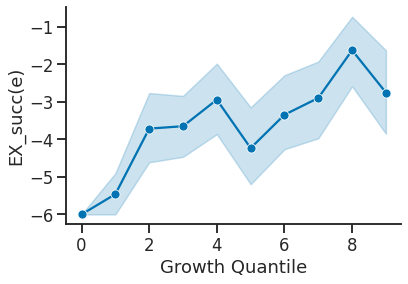

In [733]:
sns.lineplot(x='Growth Quantile',y='EX_succ(e)',data=df,marker='o')

/users/acarr/anaconda3/envs/micom/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


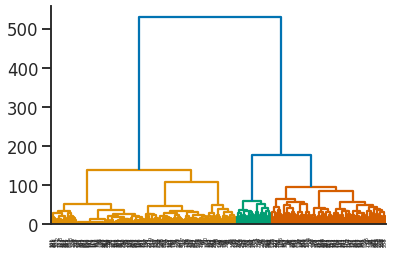

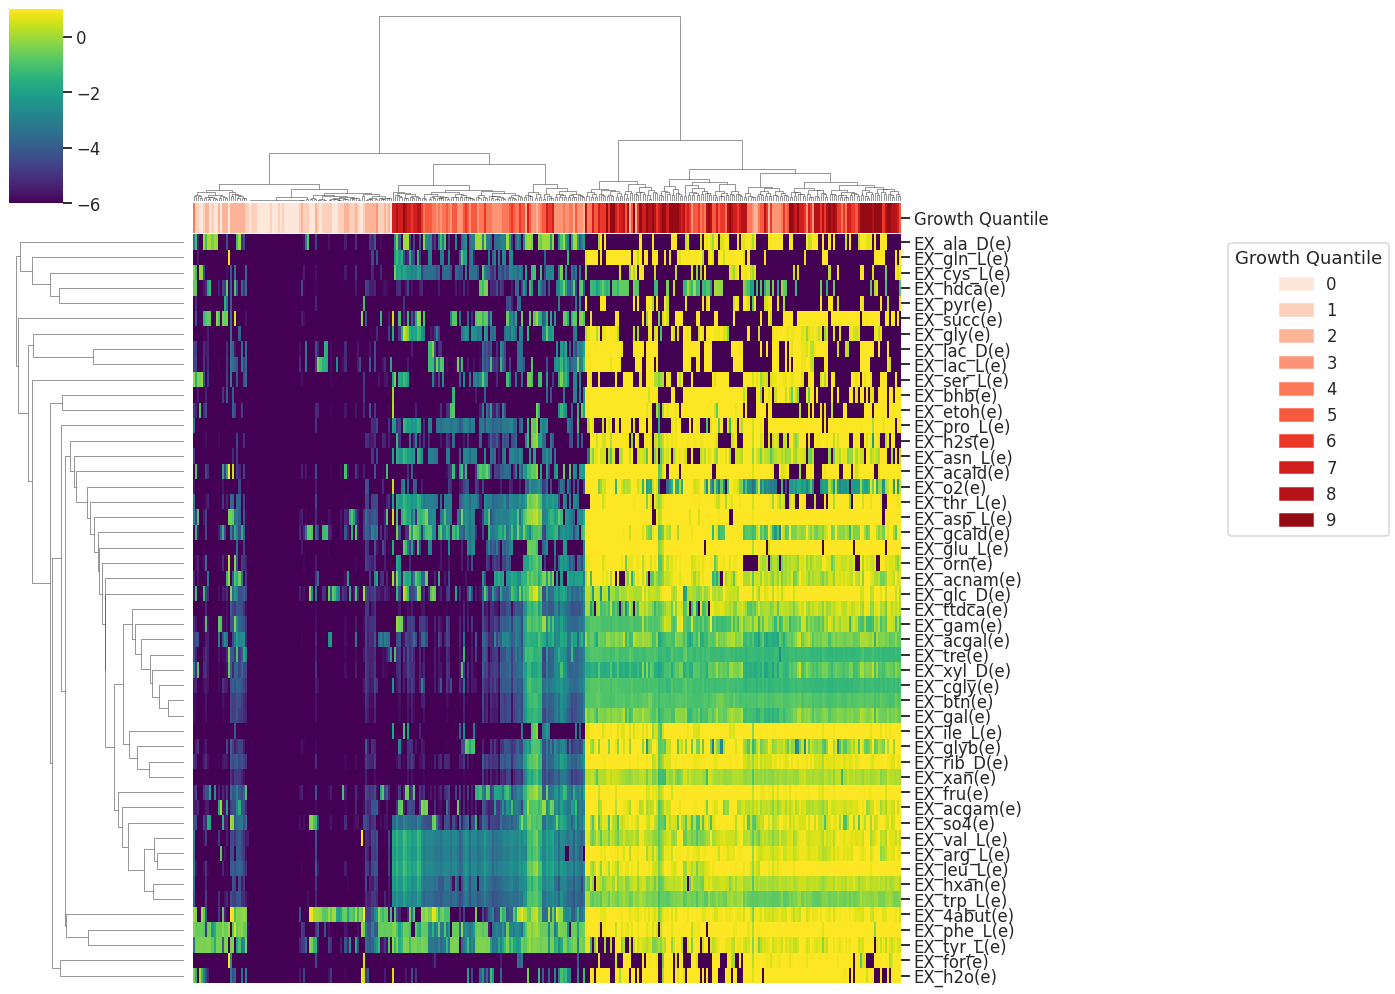

In [808]:
df = cdiff_import[(cdiff_import['sample'].isin(cdiff_growth['sample'].unique()))&(cdiff_import.tradeoff=='1.0')]

from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
import matplotlib.patches as mpatches
cols=df.columns[~df.columns.str.contains('_m')]
max_d =150
X=df[cols].iloc[:,:-8]
Z = linkage(X, 'ward')
dendro = dendrogram(Z,color_threshold=max_d)
clusters = fcluster(Z, max_d, criterion='distance')
colors=sns.color_palette('colorblind',len(pd.unique(clusters)))
cmap={i:colors[i-1] for i in pd.unique(clusters)}

n=10
df['Growth Quantile']=pd.qcut(df.log_growth,n,labels=False)
colors=sns.color_palette('Reds',n)
cmap = {}
i = 0
for group in sorted(df['Growth Quantile'].unique()):
    cmap[group] = colors[i]
    i+=1
#Use color dictionary to map color to speces column (provides color of each data point)
col_colors=df['Growth Quantile'].copy()
col_colors=col_colors.map(cmap)
idx=df[cols].iloc[:,:-8].var()[df[cols].iloc[:,:-8].var()>=4.5].index
hits=idx
clust=sns.clustermap(df[idx].T,cmap='viridis',vmin=-6,vmax=1,figsize=(15,15),col_colors=col_colors,yticklabels=1,col_linkage=Z)
order=[x.get_text() for x in clust.ax_heatmap.get_xticklabels()]
clust.ax_heatmap.set_ylabel('')
clust.ax_heatmap.set_xlabel('')
clust.ax_heatmap.set_xticks([])
#Create custom legend to include in plot 
handles = []
labels = sorted(df['Growth Quantile'].unique())
for i in range(len(sorted(labels))):
    patch = mpatches.Patch(color=colors[i],label=labels[i])
    handles.append(patch)  
clust.ax_heatmap.legend(handles=handles,bbox_to_anchor=(1.45,1),loc=2,title='Growth Quantile')
order=clust.data2d.columns
#plt.savefig('Cdiff-FMT-ImportHeatmap-v2.pdf',bbox_inches='tight')

In [1144]:
growth_rates = pd.read_pickle('12212023_natmed_growth_rates_tradeoff_pfba_species.pkl').reset_index()
growth_data=pd.merge(growth_rates,samples[['subject_name','profile_id','sample_type','time_point_days','dataset']],left_on='sample',right_on='profile_id')
growth_data=pd.merge(growth_data,dataset_meta,left_on='dataset',right_on='Dataset name')
rcdi_growth=growth_data[(growth_data['Recipient disease'].str.contains('rCDI'))]

cdiff_growth=rcdi_growth[(rcdi_growth.compartments=='Clostridioides_difficile')].copy()
cdiff_growth['log_growth']=np.log10(cdiff_growth['growth_rate'])
idx=cdiff_growth[cdiff_growth['log_growth']<-6].index
cdiff_growth.loc[idx,'log_growth']=-6
cdiff_growth

,compartments,growth_rate,abundance,sample,condition,tradeoff,subject_name,profile_id,sample_type,time_point_days,...,Grams/Volume of feces,Bowel cleansing,Route of delivery,Number of infusions,Follow-up samples after FMT,Primary (or main) outcome,Clinical outcome used for analysis,Clinical results (n° of patients who achieved the clinical outcome),Use of clinical data for analysis,log_growth
2,Clostridioides_difficile,0.058689,0.100662,ERR4290683,+cdiff,0.75,R20,ERR4290683,recipient-before,0.0,...,30-40g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-1.231442
17,Clostridioides_difficile,1.376608,0.100662,ERR4290683,+cdiff,0.85,R20,ERR4290683,recipient-before,0.0,...,30-40g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),0.138810
32,Clostridioides_difficile,0.004391,0.100662,ERR4290683,+cdiff,0.95,R20,ERR4290683,recipient-before,0.0,...,30-40g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-2.357409
56,Clostridioides_difficile,0.165315,0.100599,ERR4290680,+cdiff,0.75,D19,ERR4290680,donor,0.0,...,30-40g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-0.781686
79,Clostridioides_difficile,0.004174,0.100599,ERR4290680,+cdiff,0.85,D19,ERR4290680,donor,0.0,...,30-40g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",Week 1 and up to one year after FMT,NE,Resolution of CDI 8 weeks after FMT,8 of 8 patients,No (all succesful),-2.379470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74223,Clostridioides_difficile,0.098578,0.100109,SRR8667784,+cdiff,0.85,D15,SRR8667784,donor,NaN,...,100 g/400 ml,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-1.006221
74255,Clostridioides_difficile,0.004439,0.100109,SRR8667784,+cdiff,0.95,D15,SRR8667784,donor,NaN,...,100 g/400 ml,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-2.352727
74285,Clostridioides_difficile,0.428972,0.100247,SRR8667783,+cdiff,0.75,R14,SRR8667783,recipient-after,115.5,...,100 g/400 ml,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-0.367571
74313,Clostridioides_difficile,0.277350,0.100247,SRR8667783,+cdiff,0.85,R14,SRR8667783,recipient-after,115.5,...,100 g/400 ml,"NE (probably yes, as FMT was given by colonosc...","Colonoscopy, single","Colonoscopy, single",Up to 24 weeks after FMT,Prevalence of potentially pathogenic microbial...,Resolution of CDI,9 of 9 patients,No (all succesful),-0.556971


Text(0, 0.5, 'Community growth frac')

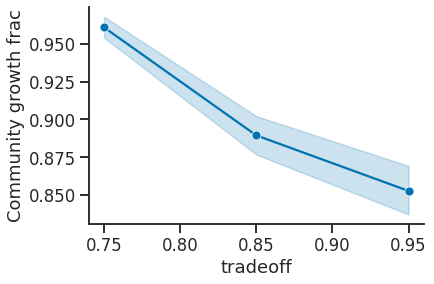

In [1146]:
growth_rates = pd.read_pickle('12212023_natmed_growth_rates_tradeoff_pfba_species.pkl').reset_index()
frac=growth_data.groupby(by=['tradeoff','sample']).apply(lambda df: df[df['growth_rate']>10**-6].shape[0]/df.shape[0])
sns.lineplot(x='tradeoff',y=0,data=frac.reset_index(),marker='o')
plt.ylabel('Community growth frac')

Text(0, 0.5, 'Community growth frac')

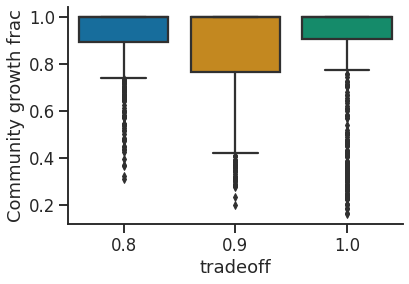

In [951]:
frac=growth_data.groupby(by=['tradeoff','sample']).apply(lambda df: df[df['growth_rate']>10**-6].shape[0]/df.shape[0])
sns.boxplot(x='tradeoff',y=0,data=frac.reset_index())
plt.ylabel('Community growth frac')

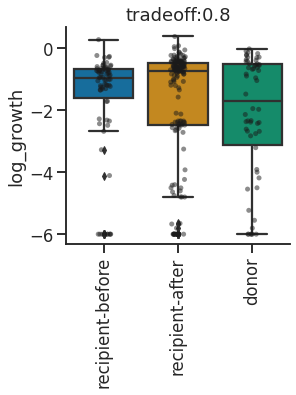

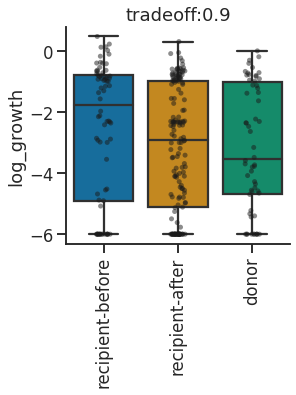

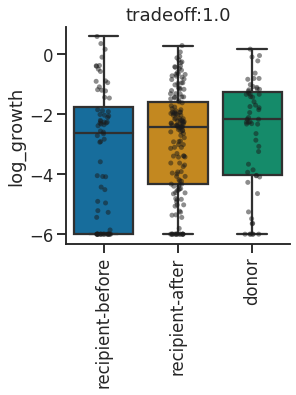

In [971]:
smps=profiles[pd.unique(ref_species_cols)].drop_duplicates()[profiles[pd.unique(ref_species_cols)].drop_duplicates().sum(axis=1)>=5].index
for idx,df in cdiff_growth[cdiff_growth['sample'].isin(smps)].groupby(by='tradeoff'):
    plt.figure(figsize=(4,4,))
    sns.boxplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after','donor'])
    sns.stripplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after','donor'],color='k',alpha=0.5)
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.title('tradeoff:%s'%idx)

In [935]:
smps=profiles[pd.unique(ref_species_cols)].drop_duplicates()[profiles[pd.unique(ref_species_cols)].drop_duplicates().sum(axis=1)>=100].index
cdiff_growth[cdiff_growth['sample'].isin(smps)]

,compartments,growth_rate,abundance,sample,condition,tradeoff,subject_name,profile_id,sample_type,time_point_days,...,Grams/Volume of feces,Bowel cleansing,Route of delivery,Number of infusions,Follow-up samples after FMT,Primary (or main) outcome,Clinical outcome used for analysis,Clinical results (n° of patients who achieved the clinical outcome),Use of clinical data for analysis,log_growth
51859,Clostridioides_difficile,1.922387e-02,0.100598,SRR13712865,+cdiff,0.8,DA_R02,SRR13712865,recipient-before,-19.0,...,80-100 g/180 ml,"PEG, 4 liters",Colonoscopy or capsules,"Colonoscopy, single, or 40 capsules as single ...",Up to 404 days after FMT,NE,Resolution of CDI 12 weeks after FMT,NE,No (metadata not available),-1.716159
51871,Clostridioides_difficile,7.077474e-03,0.100598,SRR13712865,+cdiff,0.9,DA_R02,SRR13712865,recipient-before,-19.0,...,80-100 g/180 ml,"PEG, 4 liters",Colonoscopy or capsules,"Colonoscopy, single, or 40 capsules as single ...",Up to 404 days after FMT,NE,Resolution of CDI 12 weeks after FMT,NE,No (metadata not available),-2.150122
51883,Clostridioides_difficile,5.380312e-03,0.100598,SRR13712865,+cdiff,1.0,DA_R02,SRR13712865,recipient-before,-19.0,...,80-100 g/180 ml,"PEG, 4 liters",Colonoscopy or capsules,"Colonoscopy, single, or 40 capsules as single ...",Up to 404 days after FMT,NE,Resolution of CDI 12 weeks after FMT,NE,No (metadata not available),-2.269193
56511,Clostridioides_difficile,1.445576e-01,0.100479,SRR13844393,+cdiff,0.8,Recipient.S,SRR13844393,recipient-before,NaN,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-0.839959
56525,Clostridioides_difficile,3.858537e-01,0.100479,SRR13844393,+cdiff,0.9,Recipient.S,SRR13844393,recipient-before,NaN,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-0.413577
56539,Clostridioides_difficile,5.936484e-02,0.100479,SRR13844393,+cdiff,1.0,Recipient.S,SRR13844393,recipient-before,NaN,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-1.226471
59859,Clostridioides_difficile,1.182300e-04,0.100308,SRR13844436,+cdiff,0.8,Recipient.K,SRR13844436,recipient-after,90.0,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-3.927272
59878,Clostridioides_difficile,1.134848e-02,0.100308,SRR13844436,+cdiff,0.9,Recipient.K,SRR13844436,recipient-after,90.0,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-1.945062
59897,Clostridioides_difficile,4.645157e-05,0.100308,SRR13844436,+cdiff,1.0,Recipient.K,SRR13844436,recipient-after,90.0,...,30-50g in 250ml saline,"NE (probably yes, as FMT was given also by col...","Enteroscopy and colonoscopy, single","Enteroscopy and colonoscopy, single",30 days after FMT,Resolution of CDI after FMT,Corresponding with primary outcome,21 of 21 patients,No (all succesful),-4.333000
62504,Clostridioides_difficile,1.119649e-01,0.100260,SRR15123484,+cdiff,0.8,1001311,SRR15123484,recipient-before,0.0,...,NE,Split preparation,"Enteroscopy or colonoscopy, s

0.8 full 0.6072353892059463
0.8 end point only 0.9603095882765761
0.9 full 0.061408929252524724
0.9 end point only 0.30445351243285734
1.0 full 0.16381383634891059
1.0 end point only 0.07826597731694615


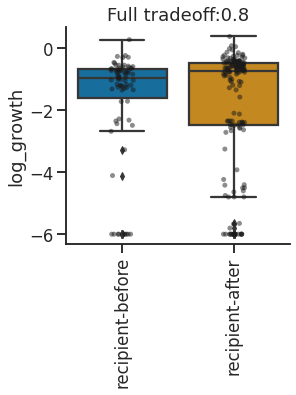

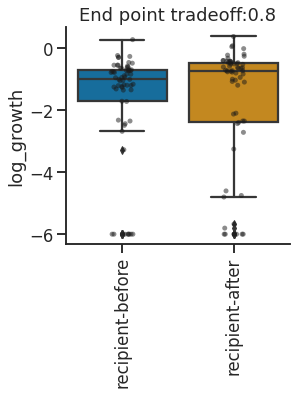

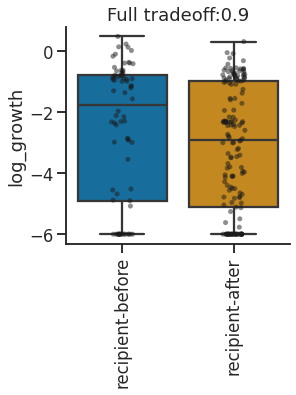

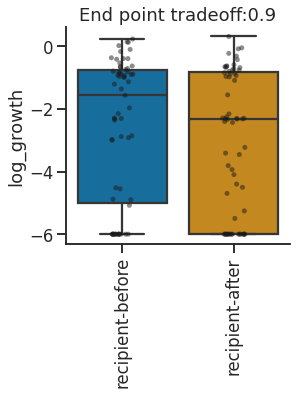

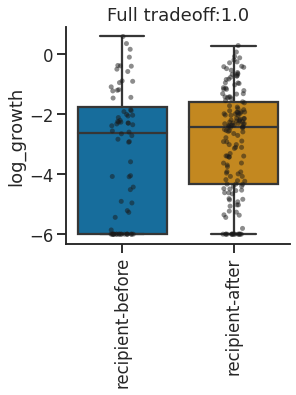

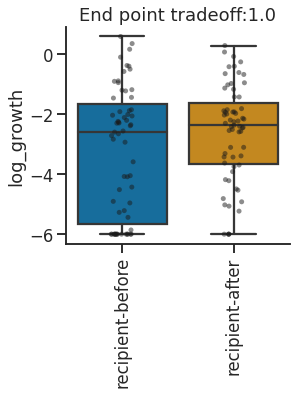

In [977]:
#from scipy.stats import wilcoxon,mannwhitneyu 
smps=profiles[pd.unique(ref_species_cols)].drop_duplicates()[profiles[pd.unique(ref_species_cols)].drop_duplicates().sum(axis=1)>=5].index
for idx,df in cdiff_growth[cdiff_growth['sample'].isin(smps)].groupby(by='tradeoff'):
    plt.figure(figsize=(4,4,))
    sns.boxplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after'])
    sns.stripplot(x='sample_type',y='log_growth',data=df,order=['recipient-before','recipient-after'],color='k',alpha=0.5)
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.title('Full tradeoff:%s'%idx)
    x=df[df.sample_type=='recipient-before'].log_growth.values
    y=df[df.sample_type=='recipient-after'].log_growth.values
    print('%s full %s'%(idx,ttest_ind(x,y,equal_var=False).pvalue))
    res=pd.DataFrame()
    for index,df2 in df[df.sample_type!='donor'].groupby(by='subject_name'):
        if True in list(df2.sample_type.str.contains('before')) and True in list(df2.sample_type.str.contains('after')):
            df2=df2.sort_values(by='time_point_days')
            if len(df2[df2.sample_type=='recipient-before'])>1:
                before=df2[df2.sample_type=='recipient-before'].iloc[[0]]
            else:
                before=df2[df2.sample_type=='recipient-before']
            if len(df2[df2.sample_type=='recipient-after']) >1:
                after=df2[df2.sample_type=='recipient-after'].iloc[[-1]]
            else:
                after=df2[df2.sample_type=='recipient-after']
            res=pd.concat([res,before,after])
    plt.figure(figsize=(4,4))
    sns.boxplot(x='sample_type',y='log_growth',data=res,order=['recipient-before','recipient-after'])
    sns.stripplot(x='sample_type',y='log_growth',data=res,order=['recipient-before','recipient-after'],color='k',alpha=0.5)
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.title('End point tradeoff:%s'%idx)
    x=res[res.sample_type=='recipient-before'].log_growth.values
    y=res[res.sample_type=='recipient-after'].log_growth.values
    print('%s end point only %s'%(idx,ttest_ind(x,y,equal_var=False).pvalue))

In [898]:
fluxes=pd.read_pickle('12112023_natmed_fluxes_tradeoff_pfba_species.pkl')
fluxes.index = pd.MultiIndex.from_tuples([tuple([str(x[0]),x[1],x[2]]) for x in fluxes[['tradeoff','sample','compartment']].values])
fluxes=fluxes.fillna(10**-6).drop(['sample','tradeoff','compartment'],axis=1)
exchanges=fluxes[fluxes.columns[['EX_' in x for x in fluxes.columns ]]]
export_flux = exchanges.copy()[[x[1] != 'community' for x in exchanges.index]]
export_flux[export_flux<=0]=10**-6
export_flux=np.log10(export_flux)
export_flux[export_flux<-6]=-6
export_flux

import_flux = exchanges.copy()[[x[1] != 'community' for x in exchanges.index]]
import_flux[import_flux >=0]=10**-6
import_flux=abs(import_flux)
import_flux=np.log10(import_flux)
import_flux=import_flux[import_flux>-6].fillna(-6)
import_flux

imprts=import_flux.reset_index()
imprts=imprts[imprts.level_2=='Clostridioides']
cdiff_rate=growth_rates[growth_rates.compartments=='Clostridioides']
cdiff_rate['tradeoff']=cdiff_rate['tradeoff'].astype(str)
cdiff_import=pd.merge(imprts,cdiff_rate,left_on=['level_0','level_1'],right_on=['tradeoff','sample'])
cdiff_import=cdiff_import.drop(['level_0','level_1','level_2'],axis=1)
cdiff_import['log_growth']=np.log10(cdiff_import.growth_rate)
cdiff_import

12062023_natmed_fluxes_tradeoff_pfba.pkl
12062023_natmed_growth_rates_tradeoff_pfba.pkl
12112023_natmed_fluxes_tradeoff_pfba_species.pkl
12112023_natmed_growth_rates_tradeoff_pfba_species.pkl
average_european_agora1.csv
average_european_agora1.qza
cooperative_tradeoff.py
genus_models/
metadata_fmts_clean_stage_II.tsv
metadata_samples_clean_stage_II.tsv
metaphlan_profiles.tsv
micom_community_builder.py
micom_v1_dbs/
models/
nat_medicine_analysis.ipynb
nat-medicine-cdiff-01.csv
nat-medicine-cdiff-01-species.csv
Supplementary_tables.xlsx
